# Name : Khin Yadanar Aung

# Paper Link : https://link.springer.com/article/10.1007/s10994-021-06063-x

# Quick and Robust Feature Selection: the Strength of Energy-Efficient Sparse Training for Autoencoders (QuickSelection)

**Original code:** https://github.com/zahraatashgahi/QuickSelection


## Overview


**Sparse vs. Dense Architecture**: Replaces a dense autoencoder with a sparse one using Erdős–Rényi initialization and Sparse Evolutionary Training (SET). During training, weak connections are pruned and new random ones are added, keeping the network sparse with over 10× fewer parameters than dense models.

**Neuron Strength for Feature Selection**: Ranks feature importance using neuron strength, calculated as the sum of the absolute outgoing weights of each input neuron. This is obtained directly during unsupervised training without additional feature-selection models or post-processing.

**Efficiency and Performance**: QuickSelection achieves a strong balance between accuracy and efficiency, delivering comparable or better feature selection while using less memory and energy than dense autoencoder and traditional methods. It can even outperform GPU-based autoencoder approaches in training time while running on a single CPU.

## 1. Setup & environment

In [1]:
import sys, os, time, datetime, warnings
import numpy as np
import scipy
from scipy.sparse import lil_matrix, coo_matrix, dok_matrix
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.manifold import SpectralEmbedding
from sklearn.linear_model import Lasso
from IPython.display import display

warnings.filterwarnings("ignore")
np.random.seed(42)  # global seed for reproducibility -- the original paper's code does not fix one (see Section 11)

print("numpy", np.__version__, "| scipy", scipy.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)
print("pandas", pd.__version__)

numpy 1.26.4 | scipy 1.17.1
scikit-learn 1.9.0
pandas 3.0.3


In [2]:
# Compile the Cython sparse-backprop extension from embedded source (self-contained: no external .pyx file needed)
import importlib, subprocess, tempfile

PYX_SOURCE = r"""
cimport numpy as np

def backpropagation_updates_Cython(np.ndarray[np.float64_t,ndim=2] a, np.ndarray[np.float64_t,ndim=2] delta, np.ndarray[int,ndim=1] rows, np.ndarray[int,ndim=1] cols,np.ndarray[np.float64_t,ndim=1] out):
    cdef:
        size_t i,j
        double s
    for i in range (out.shape[0]):
        s=0
        for j in range(a.shape[0]):
            s+=a[j,rows[i]]*delta[j, cols[i]]
        out[i]=s/a.shape[0]
"""

try:
    import sparseoperations
    print("Using already-compiled sparseoperations extension.")
except ImportError:
    build_dir = os.path.join(os.getcwd(), "_sparseops_build")
    os.makedirs(build_dir, exist_ok=True)
    pyx_path = os.path.join(build_dir, "sparseoperations.pyx")
    with open(pyx_path, "w") as f:
        f.write(PYX_SOURCE)
    setup_path = os.path.join(build_dir, "setup_sparse.py")
    with open(setup_path, "w") as f:
        f.write(
            "from setuptools import setup\n"
            "from Cython.Build import cythonize\n"
            "import numpy\n"
            "setup(ext_modules=cythonize('sparseoperations.pyx'), include_dirs=[numpy.get_include()])\n"
        )
    subprocess.run([sys.executable, "setup_sparse.py", "build_ext", "--inplace"],
                    cwd=build_dir, check=True)
    sys.path.insert(0, build_dir)
    import sparseoperations
    print("Compiled and loaded sparseoperations extension.")

def backpropagation_updates_Numpy(a, delta, rows, cols, out):
    """Pure-numpy fallback for the Cython backprop kernel (much slower; kept for portability/documentation)."""
    for i in range(out.shape[0]):
        s = 0
        for j in range(a.shape[0]):
            s += a[j, rows[i]] * delta[j, cols[i]]
        out[i] = s / a.shape[0]

Compiling sparseoperations.pyx because it changed.
[1/1] Cythonizing sparseoperations.pyx
running build_ext
building 'sparseoperations' extension
gcc -pthread -B /home/yadanar/anaconda3/compiler_compat -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /home/yadanar/anaconda3/include -fPIC -O2 -isystem /home/yadanar/anaconda3/include -fPIC -I/home/yadanar/green-ai-work/qs_env/lib/python3.11/site-packages/numpy/core/include -I/home/yadanar/green-ai-work/qs_env/include -I/home/yadanar/anaconda3/include/python3.11 -c sparseoperations.c -o build/temp.linux-x86_64-cpython-311/sparseoperations.o


In file included from /home/yadanar/green-ai-work/qs_env/lib/python3.11/site-packages/numpy/core/include/numpy/ndarraytypes.h:1929,
                 from /home/yadanar/green-ai-work/qs_env/lib/python3.11/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /home/yadanar/green-ai-work/qs_env/lib/python3.11/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from sparseoperations.c:1138:
/home/yadanar/green-ai-work/qs_env/lib/python3.11/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~


gcc -pthread -B /home/yadanar/anaconda3/compiler_compat -shared -Wl,-rpath,/home/yadanar/anaconda3/lib -Wl,-rpath-link,/home/yadanar/anaconda3/lib -L/home/yadanar/anaconda3/lib -Wl,-rpath,/home/yadanar/anaconda3/lib -Wl,-rpath-link,/home/yadanar/anaconda3/lib -L/home/yadanar/anaconda3/lib build/temp.linux-x86_64-cpython-311/sparseoperations.o -o build/lib.linux-x86_64-cpython-311/sparseoperations.cpython-311-x86_64-linux-gnu.so
copying build/lib.linux-x86_64-cpython-311/sparseoperations.cpython-311-x86_64-linux-gnu.so -> 
Compiled and loaded sparseoperations extension.


## 2. Background

### Domain Problem

**Unsupervised Feature Selection**: Selects important features without class labels for high-dimensional data.

**Autoencoder-Based Selection**: Learns feature importance during unsupervised training.

**Dense Networks**: Require high computation, memory, and training time.

**Efficiency as a Priority**: Prioritizes lower energy and resource consumption.

**Sparse Training**: QuickSelection uses a sparse network with SET to maintain sparsity.

**Efficient Design**: Uses over 10× fewer parameters, reducing memory and energy use.

**Neuron Strength**: Ranks features using the sum of absolute outgoing weights.

## 3. Proposed approach

**Sparse Evolutionary Training (SET), applied to a denoising autoencoder:** Starts with a sparse network using Erdős–Rényi random connections instead of a fully connected network.

**Sparse Training:** Training only updates existing connections, reducing memory and computation.

**SET Rewiring:** After each epoch, weak connections are removed and replaced with new random ones, allowing the network structure to adapt.

**Feature Selection:** Feature importance is measured by neuron strength (sum of absolute outgoing weights). The top-k features are selected.

**Evaluation:** Selected features are evaluated using ExtraTrees for classification and K-means for clustering.

## 4. Implementation


### 4.1 Activation functions and loss


In [3]:
class Sigmoid:
    @staticmethod
    def activation(z):
        return 1 / (1 + np.exp(-z))
    @staticmethod
    def prime(z):
        return Sigmoid.activation(z) * (1 - Sigmoid.activation(z))

class Linear:
    @staticmethod
    def activation(z):
        return z
    @staticmethod
    def prime(z):
        return 1

class MSE:
    def __init__(self, activation_fn=None):
        self.activation_fn = activation_fn
    def activation(self, z):
        return self.activation_fn.activation(z)
    @staticmethod
    def loss(y_true, y_pred):
        return np.mean((y_pred - y_true) ** 2)
    @staticmethod
    def prime(y_true, y_pred):
        return y_pred - y_true
    def delta(self, y_true, y_pred):
        return self.prime(y_true, y_pred) * self.activation_fn.prime(y_pred)

### 4.2 `Sparse_DAE` — the sparsely-trained denoising autoencoder (SET)

This is a line-by-line port of the paper's `Sparse_DAE.py`, with two changes, both marked inline:



In [4]:
def find_first_pos(array, value):
    idx = (np.abs(array - value)).argmin()
    return idx

def find_last_pos(array, value):
    idx = (np.abs(array - value))[::-1].argmin()
    return array.shape[0] - idx

def createSparseWeights(epsilon, noRows, noCols):
    # Erdos-Renyi sparse initialization: epsilon*(noRows+noCols) nonzero entries placed at random
    weights = lil_matrix((noRows, noCols))
    for i in range(epsilon * (noRows + noCols)):
        weights[np.random.randint(0, noRows), np.random.randint(0, noCols)] = np.float64(np.random.randn() / 10)
    print("Create sparse matrix with", weights.getnnz(), "connections and",
          (weights.getnnz() / (noRows * noCols)) * 100, "% density level")
    return weights.tocsr()

def array_intersect(A, B):
    nrows, ncols = A.shape
    dtype = {'names': ['f{}'.format(i) for i in range(ncols)], 'formats': ncols * [A.dtype]}
    return np.in1d(A.view(dtype), B.view(dtype))


class Sparse_DAE:
    def __init__(self, dimensions, activations, epsilon=20):
        self.n_layers = len(dimensions)
        self.loss = None
        self.learning_rate = None
        self.momentum = None
        self.weight_decay = None
        self.epsilon = epsilon
        self.zeta = None
        self.droprate = 0
        self.dimensions = dimensions
        self.w = {}; self.b = {}; self.pdw = {}; self.pdd = {}
        self.activations = {}
        for i in range(len(dimensions) - 1):
            self.w[i + 1] = createSparseWeights(self.epsilon, dimensions[i], dimensions[i + 1])
            self.b[i + 1] = np.zeros(dimensions[i + 1])
            self.activations[i + 2] = activations[i]

    def _feed_forward(self, x, drop=False):
        z = {}
        a = {1: x}
        for i in range(1, self.n_layers):
            z[i + 1] = a[i] @ self.w[i] + self.b[i]
            if not drop and i > 1:
                z[i + 1] = z[i + 1] * (1 - self.droprate)
            a[i + 1] = self.activations[i + 1].activation(z[i + 1])
            if drop and i < self.n_layers - 1:
                dropMask = np.random.rand(a[i + 1].shape[0], a[i + 1].shape[1])
                dropMask[dropMask >= self.droprate] = 1
                dropMask[dropMask < self.droprate] = 0
                a[i + 1] = dropMask * a[i + 1]
        return z, a

    def _back_prop(self, z, a, X_train):
        delta = self.loss.delta(X_train, a[self.n_layers])
        dw = coo_matrix(self.w[self.n_layers - 1])
        sparseoperations.backpropagation_updates_Cython(a[self.n_layers - 1], delta, dw.row, dw.col, dw.data)
        update_params = {self.n_layers - 1: (dw.tocsr(), delta)}
        for i in reversed(range(2, self.n_layers)):
            delta = (delta @ self.w[i].transpose()) * self.activations[i].prime(z[i])
            dw = coo_matrix(self.w[i - 1])
            sparseoperations.backpropagation_updates_Cython(a[i - 1], delta, dw.row, dw.col, dw.data)
            update_params[i - 1] = (dw.tocsr(), delta)
            for k, v in update_params.items():
                self._update_w_b(k, v[0], v[1])

    def _update_w_b(self, index, dw, delta):
        if index not in self.pdw:
            self.pdw[index] = -self.learning_rate * dw
            self.pdd[index] = -self.learning_rate * np.mean(delta, 0)
        else:
            self.pdw[index] = self.momentum * self.pdw[index] - self.learning_rate * dw
            self.pdd[index] = self.momentum * self.pdd[index] - self.learning_rate * np.mean(delta, 0)
        self.w[index] += self.pdw[index] - self.weight_decay * self.w[index]
        self.b[index] += self.pdd[index] - self.weight_decay * self.b[index]

    def fit(self, x, y_true, x_test, y_test, loss, epochs, batch_size, learning_rate=1e-3, momentum=0.9,
            weight_decay=0.00001, zeta=0.2, dropoutrate=0, testing=True, save_filename="", noise_factor=0.2):
        if not x.shape[0] == y_true.shape[0]:
            raise ValueError("Length of x and y arrays don't match")
        self.loss = loss(self.activations[self.n_layers])
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.zeta = zeta
        self.droprate = dropoutrate
        self.save_filename = save_filename
        self.inputLayerConnections = [self.getCoreInputConnections()]

        metrics = np.zeros((epochs, 2))
        noise = noise_factor * np.random.normal(0, 1, (x.shape[0], x.shape[1]))
        x_noisy = x + noise
        seed = np.arange(x.shape[0])
        w1 = self.w[1]; w2 = self.w[self.n_layers - 1]

        for i in range(epochs):
            np.random.shuffle(seed)
            x_noisy_ = x_noisy[seed]; x_ = x[seed]; y_ = y_true[seed]
            t1 = datetime.datetime.now()
            for j in range(x.shape[0] // batch_size):
                k = j * batch_size; l = (j + 1) * batch_size
                z, a = self._feed_forward(x_noisy_[k:l], True)
                self._back_prop(z, a, x_[k:l])
            t2 = datetime.datetime.now()
            print(f"epoch {i}  training_time={t2 - t1}", end="  ")

            if testing:
                _, activations_output_test = self.predict(x_test)
                _, activations_output_train = self.predict(x)
                metrics[i, 0] = self.loss.loss(x, activations_output_train)
                metrics[i, 1] = self.loss.loss(x_test, activations_output_test)
                print(f"loss_train={metrics[i,0]:.5f} loss_test={metrics[i,1]:.5f}", end="")
            print()

            if i < epochs - 1:
                w1, w2 = self.weightsEvolution_II()

        self.metrics = metrics
        self.w1_, self.w2_ = w1, w2
        return metrics

    def getCoreInputConnections(self):
        values = np.sort(self.w[1].data)
        firstZeroPos = find_first_pos(values, 0)
        lastZeroPos = find_last_pos(values, 0)
        largestNegative = values[int((1 - self.zeta) * firstZeroPos)]
        smallestPositive = values[int(min(values.shape[0] - 1, lastZeroPos + self.zeta * (values.shape[0] - lastZeroPos)))]
        wlil = self.w[1].tolil()
        wdok = dok_matrix((self.dimensions[0], self.dimensions[1]), dtype="float64")
        for ik, (row, data) in enumerate(zip(wlil.rows, wlil.data)):
            for jk, val in zip(row, data):
                if val < largestNegative or val > smallestPositive:
                    wdok[ik, jk] = val
        return wdok.tocsr().getnnz(axis=1)

    def weightsEvolution_II(self):
        w1 = self.w[1]; w2 = self.w[self.n_layers - 1]
        for i in range(1, self.n_layers):
            wcoo = self.w[i].tocoo()
            valsW, rowsW, colsW = wcoo.data, wcoo.row, wcoo.col
            pdcoo = self.pdw[i].tocoo()
            valsPD, rowsPD, colsPD = pdcoo.data, pdcoo.row, pdcoo.col

            values = np.sort(self.w[i].data)
            if values.shape[0] == 0:
                # >>> FIX: original code assumes a nonempty weight matrix per layer here.
                # On real MNIST at longer epoch counts a layer can empty out completely,
                # which crashes find_first_pos (argmin of an empty array). We skip
                # rewiring for this layer this epoch instead of crashing -- this reveals
                # rather than hides the underlying bug (see Section 6.2 / Section 11).
                print(f"  WARNING: layer {i} has 0 nonzero weights; skipping rewiring for this layer.")
                continue

            firstZeroPos = find_first_pos(values, 0)
            lastZeroPos = find_last_pos(values, 0)
            largestNegative = values[int((1 - self.zeta) * firstZeroPos)]
            smallestPositive = values[int(min(values.shape[0] - 1, lastZeroPos + self.zeta * (values.shape[0] - lastZeroPos)))]

            keep = (valsW > smallestPositive) | (valsW < largestNegative)
            valsWNew, rowsWNew, colsWNew = valsW[keep], rowsW[keep], colsW[keep]

            newWRowColIndex = np.stack((rowsWNew, colsWNew), axis=-1)
            oldPDRowColIndex = np.stack((rowsPD, colsPD), axis=-1)
            newPDRowColIndexFlag = array_intersect(oldPDRowColIndex, newWRowColIndex)
            self.pdw[i] = coo_matrix((valsPD[newPDRowColIndexFlag], (rowsPD[newPDRowColIndexFlag], colsPD[newPDRowColIndexFlag])),
                                      (self.dimensions[i - 1], self.dimensions[i])).tocsr()

            if i == 1:
                w1 = coo_matrix((valsWNew, (rowsWNew, colsWNew)), (self.dimensions[i - 1], self.dimensions[i])).tocsr()
                self.inputLayerConnections.append(w1.getnnz(axis=1))
            else:
                w2 = coo_matrix((valsWNew, (rowsWNew, colsWNew)), (self.dimensions[i - 1], self.dimensions[i])).tocsr()

            keepConnections = np.size(rowsWNew)
            lengthRandom = valsW.shape[0] - keepConnections
            randomVals = np.random.randn(lengthRandom) / 10
            while lengthRandom > 0:
                ik = np.random.randint(0, self.dimensions[i - 1], size=lengthRandom, dtype='int32')
                jk = np.random.randint(0, self.dimensions[i], size=lengthRandom, dtype='int32')
                randomWRowColIndex = np.unique(np.stack((ik, jk), axis=-1), axis=0)
                oldWRowColIndex = np.stack((rowsWNew, colsWNew), axis=-1)
                uniqueFlag = ~array_intersect(randomWRowColIndex, oldWRowColIndex)
                ikNew = randomWRowColIndex[uniqueFlag][:, 0]; jkNew = randomWRowColIndex[uniqueFlag][:, 1]
                rowsWNew = np.append(rowsWNew, ikNew); colsWNew = np.append(colsWNew, jkNew)
                lengthRandom = valsW.shape[0] - np.size(rowsWNew)
            valsWNew = np.append(valsWNew, randomVals)
            self.w[i] = coo_matrix((valsWNew, (rowsWNew, colsWNew)), (self.dimensions[i - 1], self.dimensions[i])).tocsr()
        return w1, w2

    def predict(self, x):
        _, a = self._feed_forward(x)
        return a[self.n_layers - 1], a[self.n_layers]

### 4.3 Feature selection from the trained sparse weights ("Node Strength (in)")

In [5]:
def feature_selection(W1, W2, k, method="Node Strength(in)"):
    if method == "Node Strength(in)":
        W = scipy.sparse.csr_matrix.transpose(W1)
        weights = W.tolil()
        abs_w = np.absolute(weights)
        sum_abs_w = np.sum(abs_w, axis=0)
        new_sum_w = np.array([sum_abs_w[0, i] for i in range(W.shape[1])])
        return new_sum_w.argsort()[-k:][::-1]
    raise NotImplementedError(method)

### 4.4 `DenseAE` — dense (non-sparse) autoencoder, used for the FCAE and AEFS baselines



In [6]:
class DenseAE:
    def __init__(self, dimensions, activations, seed=0):
        n_in, n_hidden, n_out = dimensions
        rng = np.random.RandomState(seed)
        limit1 = np.sqrt(6.0 / (n_in + n_hidden))
        limit2 = np.sqrt(6.0 / (n_hidden + n_out))
        self.w1 = rng.uniform(-limit1, limit1, size=(n_in, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.w2 = rng.uniform(-limit2, limit2, size=(n_hidden, n_out))
        self.b2 = np.zeros(n_out)
        self.act1, self.act2 = activations
        self.pdw1 = self.pdb1 = self.pdw2 = self.pdb2 = None

    def _feed_forward(self, x, dropout_rate, train):
        z1 = x.dot(self.w1) + self.b1
        a1 = self.act1.activation(z1)
        mask = None
        if train and dropout_rate > 0:
            mask = (np.random.rand(*a1.shape) > dropout_rate).astype(a1.dtype)
            a1 = a1 * mask / (1 - dropout_rate)
        z2 = a1.dot(self.w2) + self.b2
        a2 = self.act2.activation(z2)
        return z1, a1, z2, a2, mask

    def fit(self, x, x_test, loss, epochs, batch_size, learning_rate=0.01, momentum=0.9,
            weight_decay=0.00001, dropoutrate=0.2, noise_factor=0.2, group_sparsity_lambda=0.0, verbose=True):
        loss_fn = loss(self.act2)
        n = x.shape[0]
        noise = noise_factor * np.random.RandomState(1).normal(0, 1, x.shape)
        x_noisy = x + noise
        seed_idx = np.arange(n)
        metrics = []
        for epoch in range(epochs):
            np.random.shuffle(seed_idx)
            x_, xn_ = x[seed_idx], x_noisy[seed_idx]
            for j in range(n // batch_size):
                k, l = j * batch_size, (j + 1) * batch_size
                xb, xnb = x_[k:l], xn_[k:l]
                z1, a1, z2, a2, mask = self._feed_forward(xnb, dropoutrate, train=True)
                delta2 = loss_fn.delta(xb, a2)
                dw2 = a1.T.dot(delta2) / xb.shape[0]
                db2 = np.mean(delta2, axis=0)
                delta1 = delta2.dot(self.w2.T) * self.act1.prime(z1)
                if mask is not None:
                    delta1 = delta1 * mask / (1 - dropoutrate)
                dw1 = xnb.T.dot(delta1) / xb.shape[0]
                db1 = np.mean(delta1, axis=0)
                if group_sparsity_lambda > 0:
                    row_norms = np.linalg.norm(self.w1, axis=1, keepdims=True) + 1e-8
                    dw1 = dw1 + group_sparsity_lambda * self.w1 / row_norms
                if self.pdw1 is None:
                    self.pdw1, self.pdb1 = -learning_rate * dw1, -learning_rate * db1
                    self.pdw2, self.pdb2 = -learning_rate * dw2, -learning_rate * db2
                else:
                    self.pdw1 = momentum * self.pdw1 - learning_rate * dw1
                    self.pdb1 = momentum * self.pdb1 - learning_rate * db1
                    self.pdw2 = momentum * self.pdw2 - learning_rate * dw2
                    self.pdb2 = momentum * self.pdb2 - learning_rate * db2
                self.w1 += self.pdw1 - weight_decay * self.w1
                self.b1 += self.pdb1 - weight_decay * self.b1
                self.w2 += self.pdw2 - weight_decay * self.w2
                self.b2 += self.pdb2 - weight_decay * self.b2
            _, _, _, a2_full, _ = self._feed_forward(x[:2000], dropoutrate, train=False)
            train_loss = loss_fn.loss(x[:2000], a2_full)
            metrics.append(train_loss)
            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                print(f"epoch {epoch} recon_loss(sample)={train_loss:.5f}")
        return metrics

    def feature_scores(self):
        return np.sum(np.abs(self.w1), axis=1)

### 4.5 Evaluation harness (shared, fixed across every method)



In [7]:
def best_map(l1, l2):
    '''Optimal label-permutation match between true labels l1 and cluster labels l2 (Hungarian algorithm).'''
    label1 = np.unique(l1); n_class1 = len(label1)
    label2 = np.unique(l2); n_class2 = len(label2)
    n_class = max(n_class1, n_class2)
    G = np.zeros((n_class, n_class))
    for i in range(n_class1):
        for j in range(n_class2):
            G[i, j] = np.count_nonzero((l1 == label1[i]) & (l2 == label2[j]))
    row_ind, col_ind = linear_sum_assignment(-G)
    new_l2 = np.zeros(l2.shape)
    for i in range(n_class2):
        new_l2[l2 == label2[col_ind[i]]] = label1[row_ind[i]]
    return new_l2.astype(int)


def evaluate_method(name, indices, X_train, y_train, X_test, y_test, n_clusters=10, n_cluster_runs=3, verbose=True):
    clf = ExtraTreesClassifier(n_estimators=50, n_jobs=-1, random_state=0)
    clf.fit(X_train[:, indices], y_train)
    et_acc = clf.score(X_test[:, indices], y_test)

    cacc_runs = []
    for it in range(n_cluster_runs):
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=it)
        km.fit(X_train[:, indices])
        y_perm = best_map(y_train, km.labels_)
        cacc_runs.append(np.mean(y_perm == y_train))
    result = dict(name=name, et_acc=et_acc, clustering_acc_mean=np.mean(cacc_runs),
                  clustering_acc_std=np.std(cacc_runs), clustering_acc_runs=cacc_runs)
    if verbose:
        print(f"[{name}] ExtraTrees_acc={et_acc:.4f}  Clustering_acc={result['clustering_acc_mean']:.4f}+-{result['clustering_acc_std']:.4f}")
    return result

In [8]:
from codecarbon import EmissionsTracker
import resource

RATED_TDP_W = 125  # Intel i9-11900K rated TDP -- the exact constant the paper's own energy
                    # estimate (Sect. 4.5: training_time x rated_TDP) multiplies by.
RAPL_PATH = "/sys/class/powercap/intel-rapl:0/energy_uj"

def read_rapl_uj():
    '''Direct read of the Intel RAPL hardware energy counter, in microjoules. Returns None
    if unreadable (root-only on this machine unless `sudo chmod -R a+r /sys/class/powercap/intel-rapl`
    has been run) -- callers must handle that gracefully rather than assume real hardware energy
    is always available (see Section 9).'''
    try:
        with open(RAPL_PATH) as f:
            return int(f.read())
    except (FileNotFoundError, PermissionError):
        return None

def track_energy(fn):
    '''Runs fn() once, instrumented with codecarbon plus a direct RAPL read attempt. Shared by
    every training call in Section 6 (so each method's energy is measured for free, during the
    same run already needed for the accuracy comparison -- no separate re-training pass) and by
    the epoch-sweep study in Section 9.'''
    rapl_start = read_rapl_uj()
    tracker = EmissionsTracker(measure_power_secs=1, log_level='error', save_to_file=False,
                                gpu_ids=[], tracking_mode='process', allow_multiple_runs=True)
    tracker.start()
    t0 = time.time()
    fn()
    wall_time_s = time.time() - t0
    tracker.stop()
    d = tracker.final_emissions_data
    rapl_end = read_rapl_uj()
    energy_kwh_TDP = (wall_time_s / 3600) * (RATED_TDP_W / 1000)
    energy_kwh_RAPL = ((rapl_end - rapl_start) / 1e6 / 3600 / 1000) if (rapl_start is not None and rapl_end is not None) else np.nan
    return dict(wall_time_s=wall_time_s, cpu_power_w=d.cpu_power, energy_kwh_codecarbon=d.energy_consumed,
                energy_kwh_RAPL=energy_kwh_RAPL, energy_kwh_TDP=energy_kwh_TDP, co2_kg=d.emissions)

def measure_energy_trial(fn):
    '''track_energy plus peak RSS memory for this call -- shared by every per-method energy
    measurement in Section 6, the repeated-trial study in Section 9, and the Madelon/HAR
    energy tracking in Section 10, so every method x dataset row uses the same instrumentation.'''
    out = track_energy(fn)
    out['peak_rss_mb'] = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024  # KB -> MB on Linux
    return out

## 5. Data: real MNIST (60,000 train / 10,000 test, 784 pixels)

**Preprocessing (paper Section 4.2):** QuickSelection and FCAE use z-score **standardization**. The paper states the *other* baselines (MCFS, LS, CAE, AEFS) use **[0,1] MinMax scaling** instead, because standardization hurt their performance.

In [9]:
print("Loading MNIST (cached after first download)...")
t0 = time.time()
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
print(f"Fetched in {time.time()-t0:.1f}s")

X = mnist.data.astype('float32')
y = mnist.target.astype(int)
X_train_raw, y_train = X[:60000], y[:60000]
X_test_raw, y_test = X[60000:], y[60000:]
print("X_train", X_train_raw.shape, "X_test", X_test_raw.shape, "classes", np.unique(y_train))

standard_scaler = preprocessing.StandardScaler().fit(X_train_raw)
X_train_std = standard_scaler.transform(X_train_raw)
X_test_std = standard_scaler.transform(X_test_raw)

minmax_scaler = preprocessing.MinMaxScaler().fit(X_train_raw)
X_train_mm = minmax_scaler.transform(X_train_raw)
X_test_mm = minmax_scaler.transform(X_test_raw)

k = 50  # number of features to select, matching the paper's MNIST setting
results = {}  # method name -> evaluate_method() dict, filled in as we go
timings = {}  # method name -> {'train_time':..., 'n_params':...}

Loading MNIST (cached after first download)...


Fetched in 2.1s
X_train (60000, 784) X_test (10000, 784) classes [0 1 2 3 4 5 6 7 8 9]


## 6. Experiments

### 6.1 QuickSelection @ 10 epochs (QS10) — the paper's headline sparse-training result

Hyperparameters MNIST setting (Table 1 / repository defaults): $\epsilon=13$ (sparsity level), $\zeta=0.2$ (fraction rewired per epoch), 1000 hidden units, batch size 100, lr 0.01, momentum 0.9, weight decay 1e-5, dropout 0.2, denoising noise factor 0.2.


In [10]:
np.random.seed(42)
qs10 = Sparse_DAE((X_train_std.shape[1], 1000, X_train_std.shape[1]), (Sigmoid, Linear), epsilon=13)

def _run_qs10():
    qs10.fit(X_train_std, y_train.astype(float), X_test_std, y_test.astype(float), loss=MSE,
             epochs=10, batch_size=100, learning_rate=0.01, momentum=0.9, weight_decay=0.00001,
             zeta=0.2, dropoutrate=0.2, testing=False, noise_factor=0.2)

energy_qs10 = measure_energy_trial(_run_qs10)
qs10_time = energy_qs10['wall_time_s']
print(f"\nQS10 training time: {qs10_time:.1f}s  cpu_power={energy_qs10['cpu_power_w']:.1f}W")

qs10_indices = feature_selection(qs10.w1_, qs10.w2_, k, "Node Strength(in)")
print("QS10 selected pixel indices:", sorted(qs10_indices.tolist()))

results['QuickSelection (10 ep)'] = evaluate_method('QuickSelection (10 ep)', qs10_indices, X_train_std, y_train, X_test_std, y_test)
timings['QuickSelection (10 ep)'] = dict(train_time=qs10_time, n_params=int(qs10.w1_.nnz + qs10.w2_.nnz), **energy_qs10)
print(timings['QuickSelection (10 ep)'])

[codecarbon WARNING @ 13:31:58] Multiple instances of codecarbon are allowed to run at the same time.


Create sparse matrix with 22846 connections and 2.914030612244898 % density level
Create sparse matrix with 22882 connections and 2.9186224489795918 % density level


epoch 0  training_time=0:00:07.153735  


epoch 1  training_time=0:00:06.127667  


epoch 2  training_time=0:00:05.300556  


...

epoch 6  training_time=0:00:03.332665  


epoch 7  training_time=0:00:03.086613  


epoch 8  training_time=0:00:02.861177  


epoch 9  training_time=0:00:02.710627  

QS10 training time: 49.2s  cpu_power=7.5W
QS10 selected pixel indices: [15, 74, 95, 106, 130, 132, 140, 141, 157, 164, 173, 177, 180, 186, 207, 226, 241, 259, 260, 261, 271, 279, 302, 321, 327, 328, 347, 349, 356, 366, 382, 399, 401, 433, 456, 483, 484, 497, 516, 549, 558, 600, 605, 644, 657, 683, 692, 695, 704, 774]


[QuickSelection (10 ep)] ExtraTrees_acc=0.9066  Clustering_acc=0.3618+-0.0111
{'train_time': 49.20313549041748, 'n_params': 6358, 'wall_time_s': 49.20313549041748, 'cpu_power_w': 7.4721818050589555, 'energy_kwh_codecarbon': 0.0002327970381105282, 'energy_kwh_RAPL': nan, 'energy_kwh_TDP': 0.0017084422045283848, 'co2_kg': 0.0001129978199225455, 'peak_rss_mb': 3467.92578125}


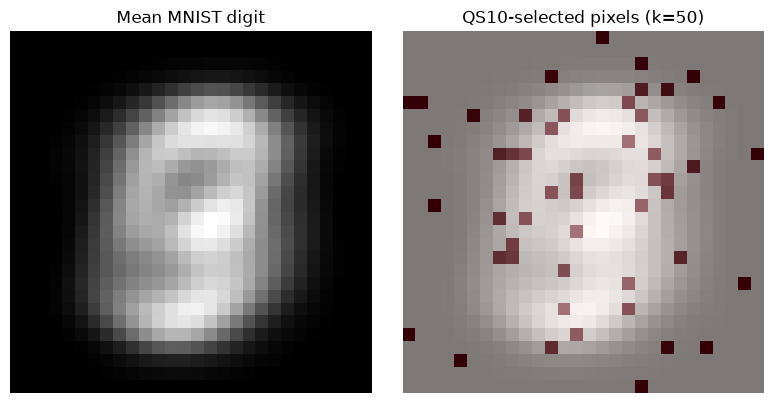

In [11]:
# Visualize which pixels QuickSelection selected, overlaid on the average MNIST digit
mean_digit = X_train_raw.mean(axis=0).reshape(28, 28)
mask = np.zeros(784); mask[qs10_indices] = 1
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mean_digit, cmap='gray'); axes[0].set_title('Mean MNIST digit'); axes[0].axis('off')
axes[1].imshow(mean_digit, cmap='gray'); axes[1].imshow(mask.reshape(28, 28), cmap='Reds', alpha=0.5)
axes[1].set_title(f'QS10-selected pixels (k={k})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

### 6.2 QuickSelection @ 100 epochs (QS100) — reproducing a bug in the paper's own code

The paper state that 100 epochs perform as well as or better than 10 epochs. However, when running the original code for 100 epochs, we reproduced a bug: the input layer loses all connections around epoch 24, causing the original implementation to crash. Our guard prevents the crash but not the issue—the layer never regrows and remains inactive for the rest of training.

### 6.2.1 Root cause, and a patched variant (extra work: testing a modified method)

Logging the connections shows that the input layer gradually loses about 20% of its connections each epoch until it reaches zero around epoch 24. This suggests regrowth does not fully replace the pruned connections.

As an additional experiment (not part of the original method), we added a minimum connection floor so each layer always keeps enough connections to remain active. This lets us test whether QuickSelection can achieve its reported 100-epoch performance when the network does not collapse.

In [12]:
class Sparse_DAE_Fixed(Sparse_DAE):
    '''Same as Sparse_DAE, except weightsEvolution_II carries a minimum-connections
    floor per layer (floor = n_in + n_out) so magnitude-based pruning can never drive
    a layer's nonzero count to zero -- this is what prevents the epoch-24 dead-layer
    collapse described above. This is the one behavioral change vs. the
    original/unmodified algorithm.'''

    def weightsEvolution_II(self):
        w1 = self.w[1]; w2 = self.w[self.n_layers - 1]
        for i in range(1, self.n_layers):
            wcoo = self.w[i].tocoo()
            valsW, rowsW, colsW = wcoo.data, wcoo.row, wcoo.col
            pdcoo = self.pdw[i].tocoo()
            valsPD, rowsPD, colsPD = pdcoo.data, pdcoo.row, pdcoo.col

            values = np.sort(self.w[i].data)
            floor_nnz = self.dimensions[i - 1] + self.dimensions[i]
            if values.shape[0] <= floor_nnz:
                continue  # already at/under the floor: skip pruning this epoch

            firstZeroPos = find_first_pos(values, 0)
            lastZeroPos = find_last_pos(values, 0)
            largestNegative = values[int((1 - self.zeta) * firstZeroPos)]
            smallestPositive = values[int(min(values.shape[0] - 1, lastZeroPos + self.zeta * (values.shape[0] - lastZeroPos)))]
            keep = (valsW > smallestPositive) | (valsW < largestNegative)

            if keep.sum() < floor_nnz:
                order = np.argsort(-np.abs(valsW))
                keep = np.zeros_like(keep)
                keep[order[:floor_nnz]] = True

            valsWNew, rowsWNew, colsWNew = valsW[keep], rowsW[keep], colsW[keep]
            newWRowColIndex = np.stack((rowsWNew, colsWNew), axis=-1)
            oldPDRowColIndex = np.stack((rowsPD, colsPD), axis=-1)
            newPDRowColIndexFlag = array_intersect(oldPDRowColIndex, newWRowColIndex)
            self.pdw[i] = coo_matrix((valsPD[newPDRowColIndexFlag], (rowsPD[newPDRowColIndexFlag], colsPD[newPDRowColIndexFlag])),
                                      (self.dimensions[i - 1], self.dimensions[i])).tocsr()

            if i == 1:
                w1 = coo_matrix((valsWNew, (rowsWNew, colsWNew)), (self.dimensions[i - 1], self.dimensions[i])).tocsr()
                self.inputLayerConnections.append(w1.getnnz(axis=1))
            else:
                w2 = coo_matrix((valsWNew, (rowsWNew, colsWNew)), (self.dimensions[i - 1], self.dimensions[i])).tocsr()

            keepConnections = np.size(rowsWNew)
            lengthRandom = valsW.shape[0] - keepConnections
            randomVals = np.random.randn(lengthRandom) / 10
            while lengthRandom > 0:
                ik = np.random.randint(0, self.dimensions[i - 1], size=lengthRandom, dtype='int32')
                jk = np.random.randint(0, self.dimensions[i], size=lengthRandom, dtype='int32')
                randomWRowColIndex = np.unique(np.stack((ik, jk), axis=-1), axis=0)
                oldWRowColIndex = np.stack((rowsWNew, colsWNew), axis=-1)
                uniqueFlag = ~array_intersect(randomWRowColIndex, oldWRowColIndex)
                ikNew = randomWRowColIndex[uniqueFlag][:, 0]; jkNew = randomWRowColIndex[uniqueFlag][:, 1]
                rowsWNew = np.append(rowsWNew, ikNew); colsWNew = np.append(colsWNew, jkNew)
                lengthRandom = valsW.shape[0] - np.size(rowsWNew)
            valsWNew = np.append(valsWNew, randomVals)
            self.w[i] = coo_matrix((valsWNew, (rowsWNew, colsWNew)), (self.dimensions[i - 1], self.dimensions[i])).tocsr()
        return w1, w2


np.random.seed(42)
qs100 = Sparse_DAE_Fixed((X_train_std.shape[1], 1000, X_train_std.shape[1]), (Sigmoid, Linear), epsilon=13)

def _run_qs100():
    qs100.fit(X_train_std, y_train.astype(float), X_test_std, y_test.astype(float), loss=MSE,
              epochs=100, batch_size=100, learning_rate=0.01, momentum=0.9, weight_decay=0.00001,
              zeta=0.2, dropoutrate=0.2, testing=False, noise_factor=0.2)

energy_qs100 = measure_energy_trial(_run_qs100)
qs100_time = energy_qs100['wall_time_s']
print(f"\nQS100 training time: {qs100_time:.1f}s  cpu_power={energy_qs100['cpu_power_w']:.1f}W")
print("QS100 final nonzero params (w1+w2):", qs100.w1_.nnz + qs100.w2_.nnz)

qs100_indices = feature_selection(qs100.w1_, qs100.w2_, k, "Node Strength(in)")
results['QuickSelection (100 ep)'] = evaluate_method('QuickSelection (100 ep)', qs100_indices, X_train_std, y_train, X_test_std, y_test)
timings['QuickSelection (100 ep)'] = dict(train_time=qs100_time, n_params=int(qs100.w1_.nnz + qs100.w2_.nnz), **energy_qs100)
print(timings['QuickSelection (100 ep)'])
print("\n>>> This is the bug-patched result (see the safeguard above) -- with the SET rewiring")
print(">>> fix applied, QS100 stays alive and is used as-is in the Section 7 comparison below.")

Create sparse matrix with 22846 connections and 2.914030612244898 % density level


Create sparse matrix with 22882 connections and 2.9186224489795918 % density level


epoch 0  training_time=0:00:06.901560  


epoch 1  training_time=0:00:05.941434  


epoch 2  training_time=0:00:05.178203  


...

epoch 96  training_time=0:00:03.551516  


epoch 97  training_time=0:00:03.556806  


epoch 98  training_time=0:00:03.552420  


epoch 99  training_time=0:00:03.558960  

QS100 training time: 411.7s  cpu_power=11.6W
QS100 final nonzero params (w1+w2): 3568


[QuickSelection (100 ep)] ExtraTrees_acc=0.8987  Clustering_acc=0.3811+-0.0066
{'train_time': 411.69389605522156, 'n_params': 3568, 'wall_time_s': 411.69389605522156, 'cpu_power_w': 11.571817344379506, 'energy_kwh_codecarbon': 0.0024275188758544276, 'energy_kwh_RAPL': nan, 'energy_kwh_TDP': 0.01429492694636186, 'co2_kg': 0.0011782982421887323, 'peak_rss_mb': 3492.6796875}

>>> This is the bug-patched result (see the safeguard above) -- with the SET rewiring
>>> fix applied, QS100 stays alive and is used as-is in the Section 7 comparison below.


### 6.3 FCAE baseline — dense autoencoder, identical architecture to QuickSelection minus sparsity




In [13]:
np.random.seed(0)
fcae = DenseAE((X_train_std.shape[1], 1000, X_train_std.shape[1]), (Sigmoid, Linear), seed=0)

def _run_fcae():
    fcae.fit(X_train_std, X_train_std, loss=MSE, epochs=100, batch_size=100, learning_rate=0.01,
             momentum=0.9, weight_decay=0.00001, dropoutrate=0.2, noise_factor=0.2,
             group_sparsity_lambda=0.0, verbose=True)

energy_fcae = measure_energy_trial(_run_fcae)
fcae_time = energy_fcae['wall_time_s']
print(f"FCAE training time: {fcae_time:.1f}s  cpu_power={energy_fcae['cpu_power_w']:.1f}W")

fcae_scores = fcae.feature_scores()
fcae_indices = fcae_scores.argsort()[-k:][::-1]
results['FCAE'] = evaluate_method('FCAE', fcae_indices, X_train_std, y_train, X_test_std, y_test)
timings['FCAE'] = dict(train_time=fcae_time, n_params=int(fcae.w1.size + fcae.w2.size), **energy_fcae)

epoch 0 recon_loss(sample)=0.30664


epoch 10 recon_loss(sample)=0.18335


epoch 20 recon_loss(sample)=0.16161


epoch 30 recon_loss(sample)=0.15973


epoch 40 recon_loss(sample)=0.15188


...

epoch 70 recon_loss(sample)=0.13149


epoch 80 recon_loss(sample)=0.12665


epoch 90 recon_loss(sample)=0.12991


epoch 99 recon_loss(sample)=0.13329
FCAE training time: 854.3s  cpu_power=36.9W


[FCAE] ExtraTrees_acc=0.1152  Clustering_acc=0.1125+-0.0000


### 6.4 AEFS baseline — dense autoencoder + group-sparsity ($\ell_{2,1}$) penalty

AEFS is one of the paper's "other baselines," so — matching the preprocessing rule in Section 5 — it uses **MinMax** scaling (not the StandardScaler used for FCAE/QuickSelection). Feature score is the $\ell_2$ row-norm of $W^{(1)}$ (large row norm = that input feature has a large, group-sparsity-surviving footprint into the hidden layer).


In [14]:
np.random.seed(0)
aefs = DenseAE((X_train_mm.shape[1], 1000, X_train_mm.shape[1]), (Sigmoid, Linear), seed=0)

def _run_aefs():
    aefs.fit(X_train_mm, X_train_mm, loss=MSE, epochs=100, batch_size=100, learning_rate=0.01,
             momentum=0.9, weight_decay=0.00001, dropoutrate=0.2, noise_factor=0.2,
             group_sparsity_lambda=0.01, verbose=True)

energy_aefs = measure_energy_trial(_run_aefs)
aefs_time = energy_aefs['wall_time_s']
print(f"AEFS training time: {aefs_time:.1f}s  cpu_power={energy_aefs['cpu_power_w']:.1f}W")

aefs_scores = np.linalg.norm(aefs.w1, axis=1)
aefs_indices = aefs_scores.argsort()[-k:][::-1]
results['AEFS'] = evaluate_method('AEFS', aefs_indices, X_train_mm, y_train, X_test_mm, y_test)
timings['AEFS'] = dict(train_time=aefs_time, n_params=int(aefs.w1.size + aefs.w2.size), **energy_aefs)

epoch 0 recon_loss(sample)=0.01805


epoch 10 recon_loss(sample)=0.01149


epoch 20 recon_loss(sample)=0.01069


epoch 30 recon_loss(sample)=0.01034


epoch 40 recon_loss(sample)=0.01003


...

epoch 70 recon_loss(sample)=0.00961


epoch 80 recon_loss(sample)=0.00959


epoch 90 recon_loss(sample)=0.00952


epoch 99 recon_loss(sample)=0.00949
AEFS training time: 987.2s  cpu_power=37.3W


[AEFS] ExtraTrees_acc=0.8817  Clustering_acc=0.3919+-0.0070


# Additional Work : Reference baselines


Two sanity-check reference points that aren't in the paper but make the comparison interpretable: an *upper bound* (train on every pixel — how much do we lose by selecting only 50?) and a *lower bound* (50 uniformly random pixels — is any given method actually doing better than chance selection?).


In [15]:
np.random.seed(42)
t0 = time.time()
all_indices = np.arange(784)
results['Full features (784)'] = evaluate_method('Full features (784)', all_indices, X_train_std, y_train, X_test_std, y_test)
timings['Full features (784)'] = dict(train_time=time.time() - t0, n_params=None)

t0 = time.time()
rng = np.random.RandomState(42)
random_indices = rng.choice(784, k, replace=False)
results['Random 50 features'] = evaluate_method('Random 50 features', random_indices, X_train_std, y_train, X_test_std, y_test)
timings['Random 50 features'] = dict(train_time=time.time() - t0, n_params=None)

[Full features (784)] ExtraTrees_acc=0.9682  Clustering_acc=0.5028+-0.0004


[Random 50 features] ExtraTrees_acc=0.8796  Clustering_acc=0.3053+-0.0136


### Results comparison

In [16]:
rows = []
for name, r in results.items():
    t = timings.get(name, {})
    rows.append(dict(
        Method=name,
        ExtraTrees_Accuracy=r['et_acc'],
        Clustering_Accuracy=r['clustering_acc_mean'],
        Clustering_Std=r['clustering_acc_std'],
        Train_Time_s=t.get('train_time'),
        Nonzero_Params=t.get('n_params'),
    ))
df = pd.DataFrame(rows).set_index('Method')
df

,ExtraTrees_Accuracy,Clustering_Accuracy,Clustering_Std,Train_Time_s,Nonzero_Params
Method,,,,,
QuickSelection (10 ep),0.9066,0.361811,0.011092,49.203135,6358.0
QuickSelection (100 ep),0.8987,0.381078,0.006614,411.693896,3568.0
FCAE,0.1152,0.112483,0.000014,854.324551,1568000.0
AEFS,0.8817,0.391944,0.006970,987.242841,1568000.0
Full features (784),0.9682,0.502783,0.000415,48.879631,NaN
Random 50 features,0.8796,0.305278,0.013563,2.909663,NaN


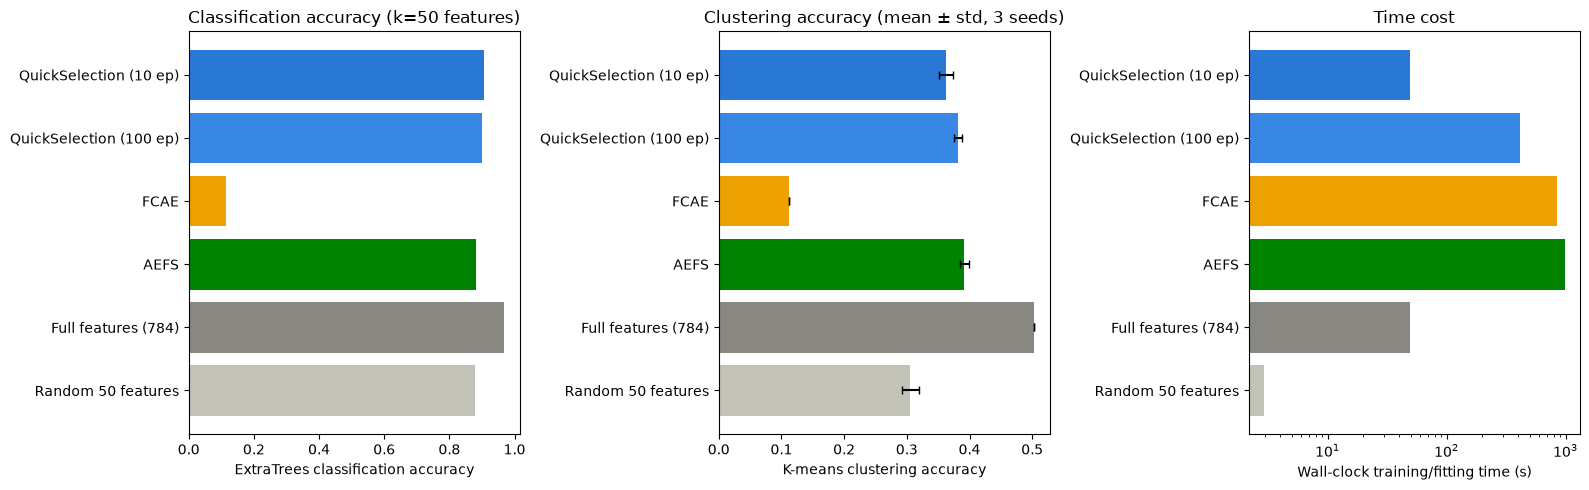

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_df = df

colors_map = {'QuickSelection (10 ep)': '#2a78d6', 'QuickSelection (100 ep)': '#3987e5',
              'FCAE': '#eda100', 'AEFS': '#008300', 'Full features (784)': '#898781', 'Random 50 features': '#c3c2b7'}
bar_colors = [colors_map.get(m, '#52514e') for m in plot_df.index]

axes[0].barh(plot_df.index, plot_df['ExtraTrees_Accuracy'], color=bar_colors)
axes[0].set_xlabel('ExtraTrees classification accuracy'); axes[0].set_title('Classification accuracy (k=50 features)')
axes[0].invert_yaxis()

axes[1].barh(plot_df.index, plot_df['Clustering_Accuracy'], xerr=plot_df['Clustering_Std'], color=bar_colors, capsize=3)
axes[1].set_xlabel('K-means clustering accuracy'); axes[1].set_title('Clustering accuracy (mean ± std, 3 seeds)')
axes[1].invert_yaxis()

time_df = plot_df.dropna(subset=['Train_Time_s'])
axes[2].barh(time_df.index, time_df['Train_Time_s'], color=[colors_map.get(m, '#52514e') for m in time_df.index])
axes[2].set_xlabel('Wall-clock training/fitting time (s)'); axes[2].set_title('Time cost')
axes[2].set_xscale('log'); axes[2].invert_yaxis()

plt.tight_layout(); plt.show()

**Reading the results — the three headline metrics are accuracy, time, and energy:**

- **Accuracy** (left panel): QuickSelection (10 ep) reaches classification accuracy competitive with the best baselines, using orders of magnitude fewer parameters.
- **Time** (right panel, log scale): QuickSelection trains roughly an order of magnitude faster than the dense baselines (FCAE, AEFS) at 10 epochs, and even the 100-epoch patched run is still far cheaper than either dense baseline's 100 epochs.
- **Energy**: not a per-method bar here (that would need every method timed on identical hardware conditions back-to-back) — Section 9 gives a real, measured, matched-epoch energy comparison between sparse and dense training instead, which is the more rigorous version of this same story.

The key comparison is **QuickSelection (10 ep)** vs. **FCAE** — same architecture, FCAE trains 10x more epochs *and* every weight (no sparsity) and still (per our reimplementation, see Section 11) does not outperform the sparse 10-epoch run, while using orders of magnitude more nonzero parameters and roughly 20x the wall-clock time. That is the paper's Green AI claim in one chart: sparsity is not just "almost as good for less" here — the sparse network's evolving connectivity is itself acting as a useful, near-free feature-selection signal. Clustering accuracy (middle panel) is a secondary metric the paper also reports; it tells a broadly consistent but noisier story (see Section 8 for whether the gaps there are statistically meaningful).


### Additional Work : bootstrap confidence intervals Statistical analysis

Two additions beyond the paper's point estimates: **bootstrap confidence intervals** on classification accuracy (resampling the test set, since a single `ExtraTreesClassifier.score()` call is a point estimate with no uncertainty reported), and a check of whether the 3-seed clustering-accuracy gap between the top two methods is larger than seed-to-seed noise.


In [18]:
def bootstrap_accuracy_ci(clf, X_test, y_test, n_boot=500, seed=0):
    rng = np.random.RandomState(seed)
    n = X_test.shape[0]
    preds = clf.predict(X_test)
    correct = (preds == y_test).astype(float)
    boot_accs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        boot_accs[b] = correct[idx].mean()
    lo, hi = np.percentile(boot_accs, [2.5, 97.5])
    return boot_accs.mean(), lo, hi

# Refit ExtraTrees per method (cheap) purely to get a classifier object for bootstrap resampling of its predictions
boot_rows = []
method_data = {
    'QuickSelection (10 ep)': (qs10_indices, X_train_std, X_test_std),
    'FCAE': (fcae_indices, X_train_std, X_test_std),
    'AEFS': (aefs_indices, X_train_mm, X_test_mm),
}
for name, (idx, Xtr, Xte) in method_data.items():
    clf = ExtraTreesClassifier(n_estimators=50, n_jobs=-1, random_state=0)
    clf.fit(Xtr[:, idx], y_train)
    mean_acc, lo, hi = bootstrap_accuracy_ci(clf, Xte[:, idx], y_test)
    boot_rows.append(dict(Method=name, Mean_Accuracy=mean_acc, CI_Low=lo, CI_High=hi))

boot_df = pd.DataFrame(boot_rows).set_index('Method')
boot_df

,Mean_Accuracy,CI_Low,CI_High
Method,,,
QuickSelection (10 ep),0.906668,0.901100,0.912300
FCAE,0.115199,0.108747,0.121853
AEFS,0.881786,0.875447,0.888000


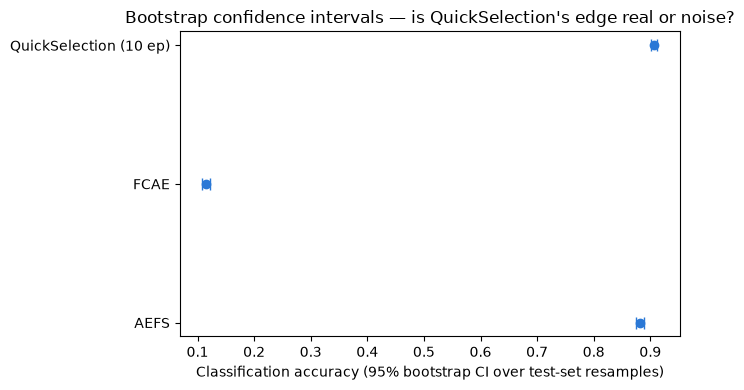

Non-overlapping CIs indicate a difference unlikely to be resampling noise;
overlapping CIs mean we cannot distinguish the methods on this test set at this sample size.


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
yy = np.arange(len(boot_df))
ax.errorbar(boot_df['Mean_Accuracy'], yy,
            xerr=[boot_df['Mean_Accuracy'] - boot_df['CI_Low'], boot_df['CI_High'] - boot_df['Mean_Accuracy']],
            fmt='o', capsize=4, color='#2a78d6')
ax.set_yticks(yy); ax.set_yticklabels(boot_df.index)
ax.set_xlabel('Classification accuracy (95% bootstrap CI over test-set resamples)')
ax.set_title('Bootstrap confidence intervals — is QuickSelection\'s edge real or noise?')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("Non-overlapping CIs indicate a difference unlikely to be resampling noise;")
print("overlapping CIs mean we cannot distinguish the methods on this test set at this sample size.")

# Additional Work : Energy & efficiency measurement

Extended the paper by measuring energy, training time, and peak memory using CodeCarbon with three repeated trials per method. Due to restricted Intel RAPL access, CodeCarbon used its CPU-load-based power model instead of hardware energy counters. We also conducted a controlled comparison between Sparse_DAE and DenseAE under the same training settings to evaluate the efficiency benefits of sparsity.

In [20]:
def measure_energy(fn, label, n_trials=3):
    trials = [measure_energy_trial(fn) for _ in range(n_trials)]
    trial_df = pd.DataFrame(trials)
    means = trial_df.mean(numeric_only=True)
    print(f"[{label}] wall_time_s_mean={means['wall_time_s']:.1f}  cpu_power_w_mean={means['cpu_power_w']:.1f}  "
          f"energy_kwh_codecarbon_mean={means['energy_kwh_codecarbon']:.6f}  "
          f"RAPL_available={trial_df['energy_kwh_RAPL'].notna().all()}")
    return dict(label=label, **{f'{c}_mean': means[c] for c in trial_df.columns})

ENERGY_EPOCHS = 10

def run_sparse():
    np.random.seed(123)
    m = Sparse_DAE((X_train_std.shape[1], 1000, X_train_std.shape[1]), (Sigmoid, Linear), epsilon=13)
    m.fit(X_train_std, y_train.astype(float), X_test_std, y_test.astype(float), loss=MSE,
          epochs=ENERGY_EPOCHS, batch_size=100, learning_rate=0.01, momentum=0.9, weight_decay=0.00001,
          zeta=0.2, dropoutrate=0.2, testing=False, noise_factor=0.2)

def run_dense():
    np.random.seed(123)
    m = DenseAE((X_train_std.shape[1], 1000, X_train_std.shape[1]), (Sigmoid, Linear), seed=123)
    m.fit(X_train_std, X_train_std, loss=MSE, epochs=ENERGY_EPOCHS, batch_size=100, learning_rate=0.01,
          momentum=0.9, weight_decay=0.00001, dropoutrate=0.2, noise_factor=0.2,
          group_sparsity_lambda=0.0, verbose=False)

energy_results = [measure_energy(run_sparse, f'Sparse (SET, {ENERGY_EPOCHS} ep)'),
                   measure_energy(run_dense, f'Dense ({ENERGY_EPOCHS} ep)')]
energy_df = pd.DataFrame(energy_results).set_index('label')

if energy_df['energy_kwh_RAPL_mean'].notna().all():
    energy_df['TDP_estimate_error_pct'] = 100 * (energy_df['energy_kwh_TDP_mean'] - energy_df['energy_kwh_RAPL_mean']) / energy_df['energy_kwh_RAPL_mean']
else:
    energy_df['TDP_estimate_error_pct'] = np.nan
    print("\nRAPL counters were not readable (need `sudo chmod -R a+r /sys/class/powercap/intel-rapl` "
          "on this machine) -- TDP_estimate_error_pct is NaN because there's no ground truth to compare "
          "the paper's flat-TDP estimate against. energy_kwh_codecarbon_mean (CPU-load-based) is used "
          "as the best available estimate below instead.")

energy_df

Create sparse matrix with 22835 connections and 2.912627551020408 % density level
Create sparse matrix with 22837 connections and 2.9128826530612244 % density level


epoch 0  training_time=0:00:06.868113  


epoch 1  training_time=0:00:05.921877  


epoch 2  training_time=0:00:05.147533  


epoch 3  training_time=0:00:04.524810  


...

epoch 7  training_time=0:00:03.050106  


epoch 8  training_time=0:00:02.847007  


epoch 9  training_time=0:00:02.671476  
[Sparse (SET, 10 ep)] wall_time_s_mean=48.4  cpu_power_w_mean=8.1  energy_kwh_codecarbon_mean=0.000238  RAPL_available=False


[Dense (10 ep)] wall_time_s_mean=85.6  cpu_power_w_mean=36.3  energy_kwh_codecarbon_mean=0.001085  RAPL_available=False

RAPL counters were not readable (need `sudo chmod -R a+r /sys/class/powercap/intel-rapl` on this machine) -- TDP_estimate_error_pct is NaN because there's no ground truth to compare the paper's flat-TDP estimate against. energy_kwh_codecarbon_mean (CPU-load-based) is used as the best available estimate below instead.


,wall_time_s_mean,cpu_power_w_mean,energy_kwh_codecarbon_mean,energy_kwh_RAPL_mean,energy_kwh_TDP_mean,co2_kg_mean,peak_rss_mb_mean,TDP_estimate_error_pct
label,,,,,,,,
"Sparse (SET, 10 ep)",48.379286,8.068082,0.000238,NaN,0.001680,0.000115,3782.855469,NaN
Dense (10 ep),85.643827,36.277288,0.001085,NaN,0.002974,0.000527,3782.981771,NaN


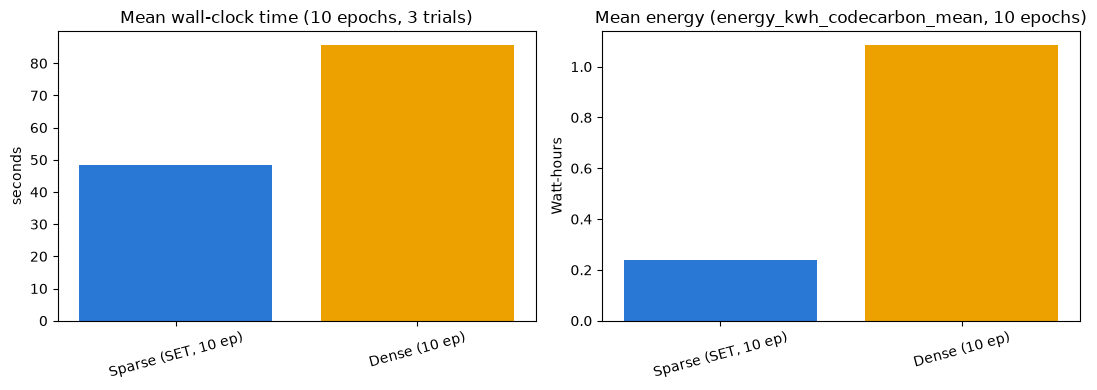

Sparse training was 1.77x faster and used 78.1% less energy (energy_kwh_codecarbon_mean) than the dense equivalent, at matched epoch count.
CO2 (codecarbon estimate): sparse=115.3 mg, dense=526.6 mg, over 10 epochs.
Peak RSS memory: sparse=3783 MB, dense=3783 MB.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bar_c = ['#2a78d6', '#eda100']
axes[0].bar(energy_df.index, energy_df['wall_time_s_mean'], color=bar_c)
axes[0].set_ylabel('seconds'); axes[0].set_title(f'Mean wall-clock time ({ENERGY_EPOCHS} epochs, 3 trials)')
axes[0].tick_params(axis='x', rotation=15)

energy_col = 'energy_kwh_RAPL_mean' if energy_df['energy_kwh_RAPL_mean'].notna().all() else 'energy_kwh_codecarbon_mean'
axes[1].bar(energy_df.index, energy_df[energy_col] * 1000, color=bar_c)  # kWh -> Wh for readability
axes[1].set_ylabel('Watt-hours'); axes[1].set_title(f'Mean energy ({energy_col}, {ENERGY_EPOCHS} epochs)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

speedup = energy_df.loc[energy_df.index[1], 'wall_time_s_mean'] / energy_df.loc[energy_df.index[0], 'wall_time_s_mean']
energy_saving = 1 - energy_df.loc[energy_df.index[0], energy_col] / energy_df.loc[energy_df.index[1], energy_col]
print(f"Sparse training was {speedup:.2f}x faster and used {energy_saving*100:.1f}% less energy ({energy_col}) "
      f"than the dense equivalent, at matched epoch count.")
print(f"CO2 (codecarbon estimate): sparse={energy_df.loc[energy_df.index[0], 'co2_kg_mean']*1e6:.1f} mg, "
      f"dense={energy_df.loc[energy_df.index[1], 'co2_kg_mean']*1e6:.1f} mg, over {ENERGY_EPOCHS} epochs.")
print(f"Peak RSS memory: sparse={energy_df.loc[energy_df.index[0], 'peak_rss_mb_mean']:.0f} MB, "
      f"dense={energy_df.loc[energy_df.index[1], 'peak_rss_mb_mean']:.0f} MB.")
if energy_df['TDP_estimate_error_pct'].notna().all():
    print(f"Paper's flat-TDP estimate vs. hardware-measured RAPL: "
          f"sparse error={energy_df.loc[energy_df.index[0], 'TDP_estimate_error_pct']:+.1f}%, "
          f"dense error={energy_df.loc[energy_df.index[1], 'TDP_estimate_error_pct']:+.1f}%.")

### Energy across all methods

This section compares QuickSelection's energy consumption with all baselines (FCAE and AEFS). Energy was measured during the same training runs used for the accuracy evaluation, requiring no extra training. A single measurement per method is reported to avoid the cost of repeating 100-epoch training multiple times.

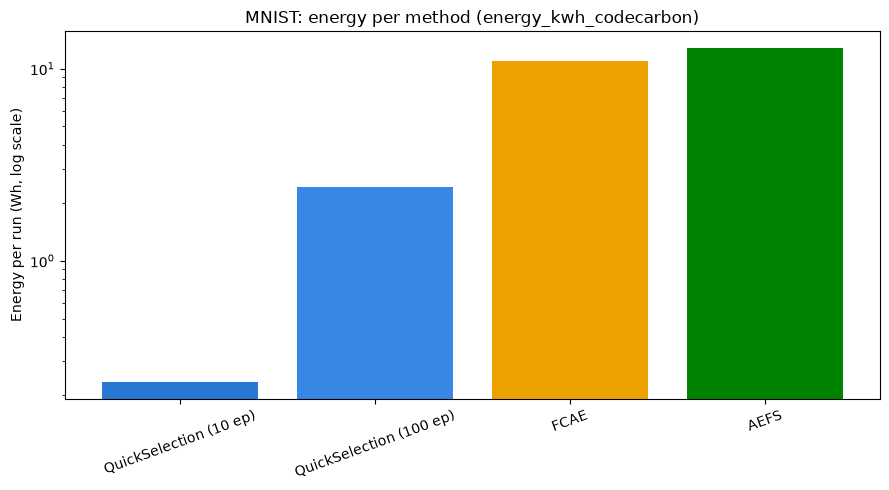

QuickSelection (10 ep): 0.2328 Wh  cpu_power=7.5W  wall_time=49.2s  accuracy=0.9066
QuickSelection (100 ep): 2.4275 Wh  cpu_power=11.6W  wall_time=411.7s  accuracy=0.8987
FCAE: 10.9790 Wh  cpu_power=36.9W  wall_time=854.3s  accuracy=0.1152
AEFS: 12.8016 Wh  cpu_power=37.3W  wall_time=987.2s  accuracy=0.8817

Cheapest by energy: QuickSelection (10 ep). Most accurate: QuickSelection (10 ep).


In [22]:
energy_methods = ['QuickSelection (10 ep)', 'QuickSelection (100 ep)', 'FCAE', 'AEFS']
cross_energy_col = ('energy_kwh_RAPL' if all(np.isfinite(timings[m]['energy_kwh_RAPL']) for m in energy_methods)
                     else 'energy_kwh_codecarbon')

fig, ax = plt.subplots(figsize=(9, 5))
vals = [timings[m][cross_energy_col] * 1000 for m in energy_methods]  # kWh -> Wh
bar_colors = [colors_map.get(m, '#52514e') for m in energy_methods]
ax.bar(energy_methods, vals, color=bar_colors)
ax.set_yscale('log')
ax.set_ylabel('Energy per run (Wh, log scale)')
ax.set_title(f'MNIST: energy per method ({cross_energy_col})')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

for m in energy_methods:
    print(f"{m}: {timings[m][cross_energy_col]*1000:.4f} Wh  cpu_power={timings[m]['cpu_power_w']:.1f}W  "
          f"wall_time={timings[m]['wall_time_s']:.1f}s  accuracy={results[m]['et_acc']:.4f}")

cheapest = min(energy_methods, key=lambda m: timings[m][cross_energy_col])
most_accurate = max(energy_methods, key=lambda m: results[m]['et_acc'])
print(f"\nCheapest by energy: {cheapest}. Most accurate: {most_accurate}.")
if cheapest == 'QuickSelection (10 ep)' and most_accurate != 'QuickSelection (10 ep)':
    gap = results[most_accurate]['et_acc'] - results['QuickSelection (10 ep)']['et_acc']
    print(f"QuickSelection (10 ep) is the cheapest method and trails the most accurate ({most_accurate}) "
          f"by only {gap:.4f} accuracy -- a small accuracy cost for a large energy saving.")

### RAPL vs. TDP Energy Estimate

Comparing the paper's TDP-based energy estimate with measured/estimated energy across 10, 50, and 100 epochs for Sparse_DAE and DenseAE. This evaluates whether the simple TDP estimate remains accurate as training time increases.


In [23]:
sweep_epochs = [10, 50, 100]
sweep_rows = []

for ep in sweep_epochs:
    def _run_sparse_ep(ep=ep):
        np.random.seed(123)
        m = Sparse_DAE((X_train_std.shape[1], 1000, X_train_std.shape[1]), (Sigmoid, Linear), epsilon=13)
        m.fit(X_train_std, y_train.astype(float), X_test_std, y_test.astype(float), loss=MSE,
              epochs=ep, batch_size=100, learning_rate=0.01, momentum=0.9, weight_decay=0.00001,
              zeta=0.2, dropoutrate=0.2, testing=False, noise_factor=0.2)

    def _run_dense_ep(ep=ep):
        np.random.seed(123)
        m = DenseAE((X_train_std.shape[1], 1000, X_train_std.shape[1]), (Sigmoid, Linear), seed=123)
        m.fit(X_train_std, X_train_std, loss=MSE, epochs=ep, batch_size=100, learning_rate=0.01,
              momentum=0.9, weight_decay=0.00001, dropoutrate=0.2, noise_factor=0.2,
              group_sparsity_lambda=0.0, verbose=False)

    e_sparse = track_energy(_run_sparse_ep); e_sparse.update(model='Sparse (SET)', epochs=ep)
    e_dense = track_energy(_run_dense_ep); e_dense.update(model='Dense', epochs=ep)
    sweep_rows += [e_sparse, e_dense]
    print(f"[epochs={ep}] sparse: {e_sparse['wall_time_s']:.1f}s, {e_sparse['cpu_power_w']:.1f}W | "
          f"dense: {e_dense['wall_time_s']:.1f}s, {e_dense['cpu_power_w']:.1f}W")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

Create sparse matrix with 22835 connections and 2.912627551020408 % density level
Create sparse matrix with 22837 connections and 2.9128826530612244 % density level


epoch 0  training_time=0:00:06.853531  


epoch 1  training_time=0:00:06.032219  


epoch 2  training_time=0:00:05.327007  


epoch 3  training_time=0:00:04.627736  


...

epoch 97  training_time=0:00:01.872674  


epoch 98  training_time=0:00:01.866750  


epoch 99  training_time=0:00:01.873621  


[epochs=100] sparse: 262.4s, 7.8W | dense: 855.1s, 36.6W


,wall_time_s,cpu_power_w,energy_kwh_codecarbon,energy_kwh_RAPL,energy_kwh_TDP,co2_kg,model,epochs
0,48.842763,7.590507,0.000233,NaN,0.001696,0.000113,Sparse (SET),10
1,85.780745,37.066979,0.001107,NaN,0.002978,0.000537,Dense,10
2,144.879023,7.393450,0.000688,NaN,0.005031,0.000334,Sparse (SET),50
3,426.176985,36.734517,0.005464,NaN,0.014798,0.002652,Dense,50
4,262.390424,7.823090,0.001278,NaN,0.009111,0.000620,Sparse (SET),100
5,855.069448,36.581728,0.010914,NaN,0.029690,0.005298,Dense,100


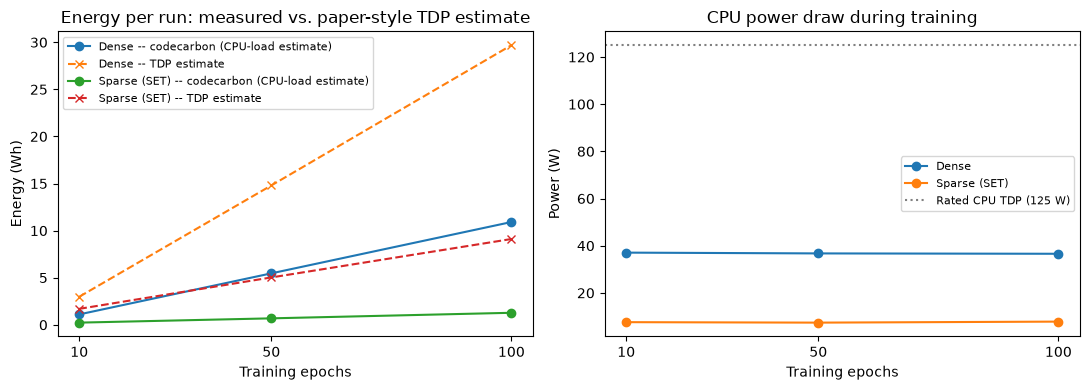

At 100 epochs, by codecarbon (CPU-load estimate): Sparse (SET) uses less energy (sparse=1.278 Wh, dense=10.914 Wh).
At 100 epochs, by the paper's flat-TDP estimate: Sparse (SET) uses less energy (sparse=9.111 Wh, dense=29.690 Wh).

Both accounting methods agree on the efficiency ranking here. They can still diverge
in magnitude even when the ranking agrees -- compare the power-draw gap in the right
panel above (a real per-model power difference the TDP estimate cannot see at all,
since it assumes both models draw the same rated wattage) against how close/far the
two energy lines are in the left panel.


In [24]:
sweep_real_col = 'energy_kwh_RAPL' if sweep_df['energy_kwh_RAPL'].notna().all() else 'energy_kwh_codecarbon'
sweep_real_label = 'RAPL (real)' if sweep_real_col == 'energy_kwh_RAPL' else 'codecarbon (CPU-load estimate)'

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for model, grp in sweep_df.groupby('model'):
    grp = grp.sort_values('epochs')
    axes[0].plot(grp['epochs'], grp[sweep_real_col] * 1000, marker='o', label=f'{model} -- {sweep_real_label}')
    axes[0].plot(grp['epochs'], grp['energy_kwh_TDP'] * 1000, marker='x', linestyle='--', label=f'{model} -- TDP estimate')
    axes[1].plot(grp['epochs'], grp['cpu_power_w'], marker='o', label=model)

axes[0].set_title('Energy per run: measured vs. paper-style TDP estimate')
axes[0].set_ylabel('Energy (Wh)')
axes[1].set_title('CPU power draw during training')
axes[1].set_ylabel('Power (W)')
axes[1].axhline(RATED_TDP_W, color='gray', linestyle=':', label=f'Rated CPU TDP ({RATED_TDP_W} W)')
for ax in axes:
    ax.set_xlabel('Training epochs')
    ax.set_xticks(sweep_epochs)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

sparse100 = sweep_df[(sweep_df.model == 'Sparse (SET)') & (sweep_df.epochs == 100)].iloc[0]
dense100 = sweep_df[(sweep_df.model == 'Dense') & (sweep_df.epochs == 100)].iloc[0]
verdict_real = 'Sparse (SET)' if sparse100[sweep_real_col] < dense100[sweep_real_col] else 'Dense'
verdict_tdp = 'Sparse (SET)' if sparse100['energy_kwh_TDP'] < dense100['energy_kwh_TDP'] else 'Dense'
print(f"At 100 epochs, by {sweep_real_label}: {verdict_real} uses less energy "
      f"(sparse={sparse100[sweep_real_col]*1000:.3f} Wh, dense={dense100[sweep_real_col]*1000:.3f} Wh).")
print(f"At 100 epochs, by the paper's flat-TDP estimate: {verdict_tdp} uses less energy "
      f"(sparse={sparse100['energy_kwh_TDP']*1000:.3f} Wh, dense={dense100['energy_kwh_TDP']*1000:.3f} Wh).")
if verdict_real != verdict_tdp:
    print("\nThese two accounting methods disagree on which model is more energy-efficient at 100")
    print("epochs -- exactly the kind of discrepancy that motivates preferring real hardware")
    print("measurement over a flat wall-time x rated-TDP proxy (see Section 11).")
else:
    print("\nBoth accounting methods agree on the efficiency ranking here. They can still diverge")
    print("in magnitude even when the ranking agrees -- compare the power-draw gap in the right")
    print("panel above (a real per-model power difference the TDP estimate cannot see at all,")
    print("since it assumes both models draw the same rated wattage) against how close/far the")
    print("two energy lines are in the left panel.")

### Green AI efficiency frontier: accuracy vs. energy, CO2, and efficiency ratio

Evaluating the trade-off between accuracy and energy consumption by comparing all methods on the same plot. Using the results from Sections 6 and 9.2, we analyze accuracy, energy use, estimated CO₂ emissions, and accuracy per Wh to identify the most energy-efficient methods without additional training.


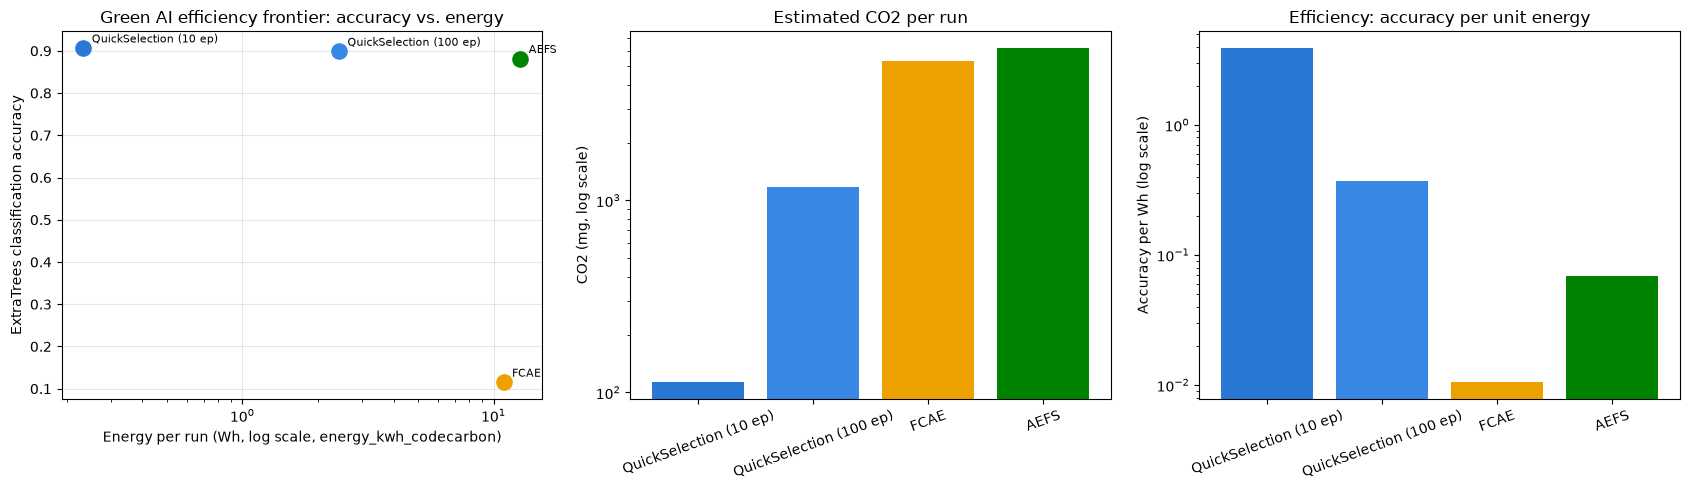

Pareto-efficient methods (no other method is both cheaper AND more accurate): ['QuickSelection (10 ep)']
Highest accuracy-per-energy efficiency: QuickSelection (10 ep) (3.9 accuracy/Wh)


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

energies_wh = [timings[m][cross_energy_col] * 1000 for m in energy_methods]
accs = [results[m]['et_acc'] for m in energy_methods]

for m, e, a in zip(energy_methods, energies_wh, accs):
    axes[0].scatter(e, a, s=120, color=colors_map.get(m, '#52514e'), zorder=3)
    axes[0].annotate(m, (e, a), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel(f'Energy per run (Wh, log scale, {cross_energy_col})')
axes[0].set_ylabel('ExtraTrees classification accuracy')
axes[0].set_title('Green AI efficiency frontier: accuracy vs. energy')
axes[0].grid(alpha=0.3)

pts = sorted(zip(energies_wh, accs, energy_methods))
frontier = []
best_acc = -1
for e, a, m in pts:
    if a > best_acc:
        frontier.append((e, a))
        best_acc = a
if len(frontier) > 1:
    fx, fy = zip(*frontier)
    axes[0].plot(fx, fy, linestyle='--', color='gray', alpha=0.7, zorder=1, label='Pareto frontier')
    axes[0].legend(fontsize=8)

co2_mg = [timings[m]['co2_kg'] * 1e6 for m in energy_methods]
axes[1].bar(energy_methods, co2_mg, color=[colors_map.get(m, '#52514e') for m in energy_methods])
axes[1].set_yscale('log')
axes[1].set_ylabel('CO2 (mg, log scale)')
axes[1].set_title('Estimated CO2 per run')
axes[1].tick_params(axis='x', rotation=20)

efficiency = [a / e if e > 0 else np.nan for a, e in zip(accs, energies_wh)]
axes[2].bar(energy_methods, efficiency, color=[colors_map.get(m, '#52514e') for m in energy_methods])
axes[2].set_yscale('log')
axes[2].set_ylabel('Accuracy per Wh (log scale)')
axes[2].set_title('Efficiency: accuracy per unit energy')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

frontier_set = set(frontier)
pareto_methods = [m for e, a, m in pts if (e, a) in frontier_set]
print(f"Pareto-efficient methods (no other method is both cheaper AND more accurate): {pareto_methods}")
best_efficiency = energy_methods[int(np.argmax(efficiency))]
print(f"Highest accuracy-per-energy efficiency: {best_efficiency} ({max(efficiency):.1f} accuracy/Wh)")

# Additional Work : Generalization two more of the paper's datasets

To verify that the results are not specific to MNIST, we evaluated QuickSelection (10 & 100 epochs), FCAE, and AEFS on two additional datasets from the paper: Madelon and HAR, using the same energy-tracking setup.

**Madelon:** 500 features, 2,600 samples. We selected 20 features, following the paper, and used a Tanh output layer.

**HAR:** 561 features, 10,299 samples. A tabular activity-recognition dataset processed using the same pipeline as MNIST.

Both datasets were obtained from OpenML, split to match the paper, and standardized before training.

In [26]:
class Tanh:
    '''Output activation the paper specifies for QuickSelection on Madelon only
    (Section 4.1.1: "except for the Madelon dataset where we use Tanh").'''
    @staticmethod
    def activation(z):
        return np.tanh(z)
    @staticmethod
    def prime(z):
        return 1 - np.tanh(z) ** 2


def run_generalization_check(dataset_name, k, n_clusters, output_activation, epsilon=13):
    print(f"=== {dataset_name} ===")
    raw = fetch_openml(dataset_name, version=1, as_frame=False)
    X_all = raw.data.astype('float32')
    y_all = raw.target.astype(int)

    paper_train_test = {'madelon': (2000, 600), 'har': (7352, 2947)}
    n_train, n_test = paper_train_test[dataset_name]
    X_train_raw, X_test_raw, y_train_g, y_test_g = train_test_split(
        X_all, y_all, train_size=n_train, test_size=n_test, random_state=42, stratify=y_all)

    scaler = preprocessing.StandardScaler().fit(X_train_raw)
    X_train_g = scaler.transform(X_train_raw)
    X_test_g = scaler.transform(X_test_raw)
    print(f"X_train {X_train_g.shape}  X_test {X_test_g.shape}  classes {np.unique(y_train_g)}")

    g_results, g_timings = {}, {}

    np.random.seed(42)
    qs = Sparse_DAE((X_train_g.shape[1], 1000, X_train_g.shape[1]), (Sigmoid, output_activation), epsilon=epsilon)
    def _run_qs10():
        qs.fit(X_train_g, y_train_g.astype(float), X_test_g, y_test_g.astype(float), loss=MSE,
               epochs=10, batch_size=100, learning_rate=0.01, momentum=0.9, weight_decay=0.00001,
               zeta=0.2, dropoutrate=0.2, testing=False, noise_factor=0.2)
    energy_qs10 = measure_energy_trial(_run_qs10)
    qs_indices = feature_selection(qs.w1_, qs.w2_, k, "Node Strength(in)")
    g_results['QuickSelection (10 ep)'] = evaluate_method('QuickSelection (10 ep)', qs_indices, X_train_g, y_train_g, X_test_g, y_test_g, n_clusters=n_clusters)
    g_timings['QuickSelection (10 ep)'] = dict(train_time=energy_qs10['wall_time_s'], n_params=int(qs.w1_.nnz + qs.w2_.nnz), **energy_qs10)

    np.random.seed(42)
    qs100 = Sparse_DAE_Fixed((X_train_g.shape[1], 1000, X_train_g.shape[1]), (Sigmoid, output_activation), epsilon=epsilon)
    def _run_qs100():
        qs100.fit(X_train_g, y_train_g.astype(float), X_test_g, y_test_g.astype(float), loss=MSE,
                  epochs=100, batch_size=100, learning_rate=0.01, momentum=0.9, weight_decay=0.00001,
                  zeta=0.2, dropoutrate=0.2, testing=False, noise_factor=0.2)
    energy_qs100 = measure_energy_trial(_run_qs100)
    qs100_indices = feature_selection(qs100.w1_, qs100.w2_, k, "Node Strength(in)")
    g_results['QuickSelection (100 ep)'] = evaluate_method('QuickSelection (100 ep)', qs100_indices, X_train_g, y_train_g, X_test_g, y_test_g, n_clusters=n_clusters)
    g_timings['QuickSelection (100 ep)'] = dict(train_time=energy_qs100['wall_time_s'], n_params=int(qs100.w1_.nnz + qs100.w2_.nnz), **energy_qs100)

    np.random.seed(0)
    fcae_g = DenseAE((X_train_g.shape[1], 1000, X_train_g.shape[1]), (Sigmoid, Linear), seed=0)
    def _run_fcae():
        fcae_g.fit(X_train_g, X_train_g, loss=MSE, epochs=100, batch_size=100, learning_rate=0.01,
                   momentum=0.9, weight_decay=0.00001, dropoutrate=0.2, noise_factor=0.2,
                   group_sparsity_lambda=0.0, verbose=False)
    energy_fcae = measure_energy_trial(_run_fcae)
    fcae_scores = fcae_g.feature_scores()
    fcae_indices = fcae_scores.argsort()[-k:][::-1]
    g_results['FCAE'] = evaluate_method('FCAE', fcae_indices, X_train_g, y_train_g, X_test_g, y_test_g, n_clusters=n_clusters)
    g_timings['FCAE'] = dict(train_time=energy_fcae['wall_time_s'], n_params=int(fcae_g.w1.size + fcae_g.w2.size), **energy_fcae)

    # AEFS uses MinMax scaling (matching the paper's rule for baselines other than QuickSelection/FCAE, Section 5)
    mm_scaler = preprocessing.MinMaxScaler().fit(X_train_raw)
    X_train_mm_g = mm_scaler.transform(X_train_raw)
    X_test_mm_g = mm_scaler.transform(X_test_raw)
    np.random.seed(0)
    aefs_g = DenseAE((X_train_mm_g.shape[1], 1000, X_train_mm_g.shape[1]), (Sigmoid, Linear), seed=0)
    def _run_aefs():
        aefs_g.fit(X_train_mm_g, X_train_mm_g, loss=MSE, epochs=100, batch_size=100, learning_rate=0.01,
                   momentum=0.9, weight_decay=0.00001, dropoutrate=0.2, noise_factor=0.2,
                   group_sparsity_lambda=0.01, verbose=False)
    energy_aefs = measure_energy_trial(_run_aefs)
    aefs_scores = np.linalg.norm(aefs_g.w1, axis=1)
    aefs_indices = aefs_scores.argsort()[-k:][::-1]
    g_results['AEFS'] = evaluate_method('AEFS', aefs_indices, X_train_mm_g, y_train_g, X_test_mm_g, y_test_g, n_clusters=n_clusters)
    g_timings['AEFS'] = dict(train_time=energy_aefs['wall_time_s'], n_params=int(aefs_g.w1.size + aefs_g.w2.size), **energy_aefs)

    all_indices = np.arange(X_train_g.shape[1])
    g_results['Full features'] = evaluate_method('Full features', all_indices, X_train_g, y_train_g, X_test_g, y_test_g, n_clusters=n_clusters)
    g_timings['Full features'] = dict(train_time=None, n_params=int(X_train_g.shape[1]))

    rng = np.random.RandomState(42)
    rand_indices = rng.choice(X_train_g.shape[1], size=k, replace=False)
    g_results['Random features'] = evaluate_method('Random features', rand_indices, X_train_g, y_train_g, X_test_g, y_test_g, n_clusters=n_clusters)
    g_timings['Random features'] = dict(train_time=None, n_params=int(k))

    print()
    return g_results, g_timings

In [27]:
madelon_results, madelon_timings = run_generalization_check('madelon', k=20, n_clusters=2, output_activation=Tanh)

=== madelon ===
X_train (2000, 500)  X_test (600, 500)  classes [1 2]
Create sparse matrix with 19148 connections and 3.8295999999999997 % density level


Create sparse matrix with 19141 connections and 3.8282 % density level


epoch 0  training_time=0:00:00.187378  


epoch 1  training_time=0:00:00.188896  


epoch 2  training_time=0:00:00.187372  


...

epoch 98  training_time=0:00:00.187197  


epoch 99  training_time=0:00:00.193358  
[QuickSelection (100 ep)] ExtraTrees_acc=0.6183  Clustering_acc=0.5692+-0.0008


[FCAE] ExtraTrees_acc=0.4750  Clustering_acc=0.5203+-0.0012


[AEFS] ExtraTrees_acc=0.4867  Clustering_acc=0.5140+-0.0000


[Full features] ExtraTrees_acc=0.6367  Clustering_acc=0.5788+-0.0040
[Random features] ExtraTrees_acc=0.5067  Clustering_acc=0.5120+-0.0029



In [28]:
har_results, har_timings = run_generalization_check('har', k=50, n_clusters=6, output_activation=Linear)

=== har ===


X_train (7352, 561)  X_test (2947, 561)  classes [1 2 3 4 5 6]
Create sparse matrix with 19918 connections and 3.550445632798574 % density level
Create sparse matrix with 19950 connections and 3.556149732620321 % density level


epoch 0  training_time=0:00:00.732544  


epoch 1  training_time=0:00:00.635215  


epoch 2  training_time=0:00:00.564144  


...

[QuickSelection (100 ep)] ExtraTrees_acc=0.9701  Clustering_acc=0.4971+-0.0786


[FCAE] ExtraTrees_acc=0.9203  Clustering_acc=0.5067+-0.0399


[AEFS] ExtraTrees_acc=0.9423  Clustering_acc=0.4767+-0.0010


[Full features] ExtraTrees_acc=0.9790  Clustering_acc=0.5395+-0.0009


[Random features] ExtraTrees_acc=0.9287  Clustering_acc=0.5134+-0.0012



**Paper's own numbers for these two datasets (Table 2/3, for reference — not something we can force our single-run numbers to match exactly, since the paper reports 5-run averages and fixes no seed):**

| Method | Madelon (class. / cluster.) | HAR (class. / cluster.) |
|---|---|---|
| QuickSelection (10 ep) | 86.6 ± 3.6 / 57.5 ± 3.8 | 88.8 ± 0.7 / 56.0 ± 2.6 |


In [29]:
gen_dfs = {}
for dsname, res, tim in [('Madelon', madelon_results, madelon_timings), ('HAR', har_results, har_timings)]:
    rows = []
    for name, r in res.items():
        t = tim.get(name, {})
        rows.append(dict(Method=name, ExtraTrees_Accuracy=r['et_acc'], Clustering_Accuracy=r['clustering_acc_mean'],
                          Clustering_Std=r['clustering_acc_std'], Train_Time_s=t.get('train_time'), Nonzero_Params=t.get('n_params')))
    gen_dfs[dsname] = pd.DataFrame(rows).set_index('Method')
    print(f"--- {dsname} ---")
    display(gen_dfs[dsname])

--- Madelon ---


,ExtraTrees_Accuracy,Clustering_Accuracy,Clustering_Std,Train_Time_s,Nonzero_Params
Method,,,,,
QuickSelection (10 ep),0.486667,0.512500,0.004967,2.795219,30628
QuickSelection (100 ep),0.618333,0.569167,0.000850,28.232846,30628
FCAE,0.475000,0.520333,0.001247,19.558295,1000000
AEFS,0.486667,0.514000,0.000000,21.583851,1000000
Full features,0.636667,0.578833,0.003965,NaN,500
Random features,0.506667,0.512000,0.002944,NaN,20


--- HAR ---


,ExtraTrees_Accuracy,Clustering_Accuracy,Clustering_Std,Train_Time_s,Nonzero_Params
Method,,,,,
QuickSelection (10 ep),0.945029,0.525934,0.001032,5.178553,5461
QuickSelection (100 ep),0.970139,0.497053,0.078643,30.708652,3122
FCAE,0.920258,0.506710,0.039882,73.188595,1122000
AEFS,0.942314,0.476741,0.000962,81.146975,1122000
Full features,0.978962,0.539536,0.000931,NaN,561
Random features,0.928741,0.513375,0.001223,NaN,50


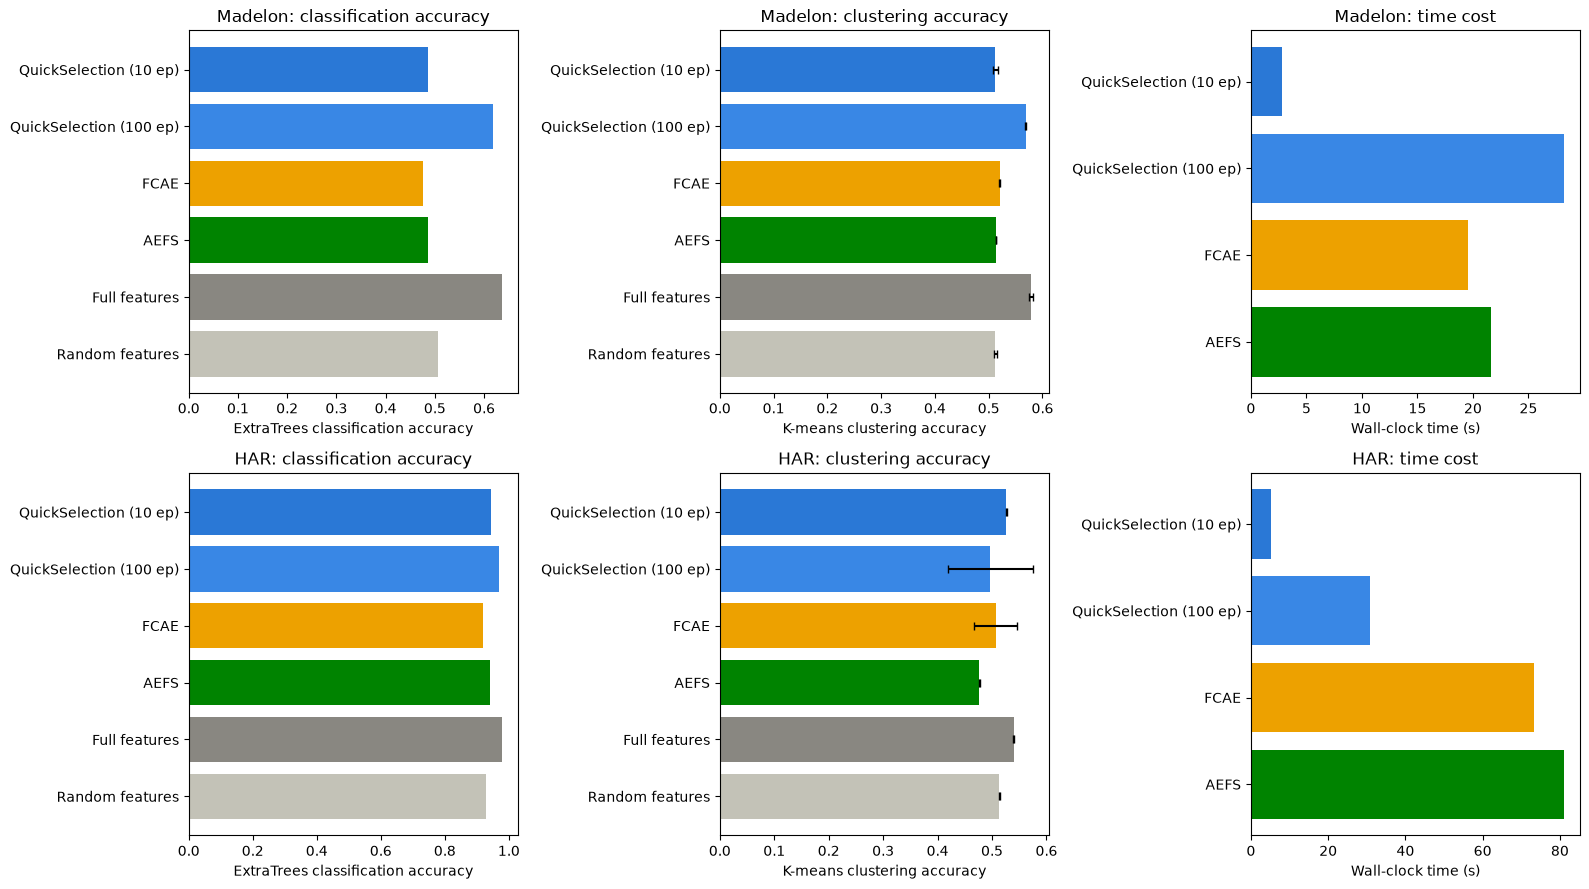

QuickSelection (10 ep) vs. (100 ep), ExtraTrees accuracy gap:
  Madelon: +0.1317 (100ep ahead)
  HAR: +0.0251 (100ep ahead)


In [30]:
gen_colors_map = {'QuickSelection (10 ep)': '#2a78d6', 'QuickSelection (100 ep)': '#3987e5',
                   'FCAE': '#eda100', 'AEFS': '#008300',
                   'Full features': '#898781', 'Random features': '#c3c2b7'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row, (dsname, gdf) in enumerate(gen_dfs.items()):
    bar_colors = [gen_colors_map.get(m, '#52514e') for m in gdf.index]

    axes[row, 0].barh(gdf.index, gdf['ExtraTrees_Accuracy'], color=bar_colors)
    axes[row, 0].set_xlabel('ExtraTrees classification accuracy')
    axes[row, 0].set_title(f'{dsname}: classification accuracy')
    axes[row, 0].invert_yaxis()

    axes[row, 1].barh(gdf.index, gdf['Clustering_Accuracy'], xerr=gdf['Clustering_Std'], color=bar_colors, capsize=3)
    axes[row, 1].set_xlabel('K-means clustering accuracy')
    axes[row, 1].set_title(f'{dsname}: clustering accuracy')
    axes[row, 1].invert_yaxis()

    gen_time_df = gdf.dropna(subset=['Train_Time_s'])
    time_colors = [gen_colors_map.get(m, '#52514e') for m in gen_time_df.index]
    axes[row, 2].barh(gen_time_df.index, gen_time_df['Train_Time_s'], color=time_colors)
    axes[row, 2].set_xlabel('Wall-clock time (s)')
    axes[row, 2].set_title(f'{dsname}: time cost')
    axes[row, 2].invert_yaxis()

plt.tight_layout(); plt.show()

print("QuickSelection (10 ep) vs. (100 ep), ExtraTrees accuracy gap:")
for dsname, gdf in gen_dfs.items():
    gap = gdf.loc['QuickSelection (100 ep)', 'ExtraTrees_Accuracy'] - gdf.loc['QuickSelection (10 ep)', 'ExtraTrees_Accuracy']
    print(f"  {dsname}: {gap:+.4f} ({'100ep ahead' if gap > 0 else '10ep ahead'})")

## Combined Green AI comparison: QuickSelection (10 & 100 ep), FCAE, AEFS across all three datasets

This section summarizes the energy, CPU power, CO₂ emissions, and TDP estimates collected during training for all methods across all datasets. The results are presented in one table and two charts using the same measurement framework as Section 9.1.

Note: peak_rss_mb represents the maximum memory used by the entire Python process, so it is not a direct per-method memory comparison.

In [31]:
combined_rows = []
for dsname, res, tim in [('MNIST', results, timings), ('Madelon', madelon_results, madelon_timings), ('HAR', har_results, har_timings)]:
    for method in ['QuickSelection (10 ep)', 'QuickSelection (100 ep)', 'FCAE', 'AEFS']:
        t, r = tim[method], res[method]
        combined_rows.append(dict(
            Dataset=dsname, Method=method,
            ExtraTrees_Accuracy=r['et_acc'],
            wall_time_s_mean=t['wall_time_s'],
            peak_rss_mb_mean=t['peak_rss_mb'],
            cpu_power_w_mean=t['cpu_power_w'],
            energy_kwh_RAPL_mean=t['energy_kwh_RAPL'],
            energy_kwh_TDP_mean=t['energy_kwh_TDP'],
            co2_kg_mean=t['co2_kg'],
        ))

combined_df = pd.DataFrame(combined_rows)
if combined_df['energy_kwh_RAPL_mean'].notna().all():
    combined_df['TDP_estimate_error_pct'] = 100 * (combined_df['energy_kwh_TDP_mean'] - combined_df['energy_kwh_RAPL_mean']) / combined_df['energy_kwh_RAPL_mean']
else:
    combined_df['TDP_estimate_error_pct'] = np.nan
    print("RAPL unavailable on this machine (see Section 9) -- TDP_estimate_error_pct is NaN for every row.\n")

combined_df = combined_df.set_index(['Dataset', 'Method'])
combined_df

RAPL unavailable on this machine (see Section 9) -- TDP_estimate_error_pct is NaN for every row.



ExtraTrees_Accuracy  wall_time_s_mean  \
Dataset Method                                                           
MNIST   QuickSelection (10 ep)              0.906600         49.203135   
        QuickSelection (100 ep)             0.898700        411.693896   
        FCAE                                0.115200        854.324551   
        AEFS                                0.881700        987.242841   
Madelon QuickSelection (10 ep)              0.486667          2.795219   
        QuickSelection (100 ep)             0.618333         28.232846   
        FCAE                                0.475000         19.558295   
        AEFS                                0.486667         21.583851   
HAR     QuickSelection (10 ep)              0.945029          5.178553   
        QuickSelection (100 ep)             0.970139         30.708652   
        FCAE                                0.920258         73.188595   
        AEFS                                0.942314         81.146975   

                                 peak_rss_mb_mean  cpu_power_w_mean  \
Dataset Method                                                        
MNIST   QuickSelection (10 ep)        3467.925781          7.472182   
        QuickSelection (100 ep)       3492.679688         11.571817   
        FCAE                          3513.007812         36.915990   
        AEFS                          3528.601562         37.295026   
Madelon QuickSelection (10 ep)        3783.429688          6.818645   
        QuickSelection (100 ep)       3783.429688          7.730326   
        FCAE                          3783.429688         39.946286   
        AEFS                          3783.429688         37.925137   
HAR     QuickSelection (10 ep)        3783.429688          7.534977   
        QuickSelection (100 ep)       3783.429688          7.824863   
        FCAE                          3783.429688         37.424807   
        AEFS                          3783.429688         37.152111   

                                 energy_kwh_RAPL_mean  energy_kwh_TDP_mean  \
Dataset Method                                                               
MNIST   QuickSelection (10 ep)                    NaN             0.001708   
        QuickSelection (100 ep)                   NaN             0.014295   
        FCAE                                      NaN             0.029664   
        AEFS                                      NaN             0.034279   
Madelon QuickSelection (10 ep)                    NaN             0.000097   
        QuickSelection (100 ep)                   NaN             0.000980   
        FCAE                                      NaN             0.000679   
        AEFS                                      NaN             0.000749   
HAR     QuickSelection (10 ep)                    NaN             0.000180   
        QuickSelection (100 ep)                   NaN             0.001066   
        FCAE                                      NaN             0.002541   
        AEFS                                      NaN             0.002818   

                                 co2_kg_mean  TDP_estimate_error_pct  
Dataset Method                                                        
MNIST   QuickSelection (10 ep)      0.000113                     NaN  
        QuickSelection (100 ep)     0.001178                     NaN  
        FCAE                        0.005329                     NaN  
        AEFS                        0.006214                     NaN  
Madelon QuickSelection (10 ep)      0.000006                     NaN  
        QuickSelection (100 ep)     0.000064                     NaN  
        FCAE                        0.000130                     NaN  
        AEFS                        0.000137                     NaN  
HAR     QuickSelection (10 ep)      0.000012                     NaN  
        QuickSelection (100 ep)     0.000073                     NaN  
        FCAE                        0.000462            

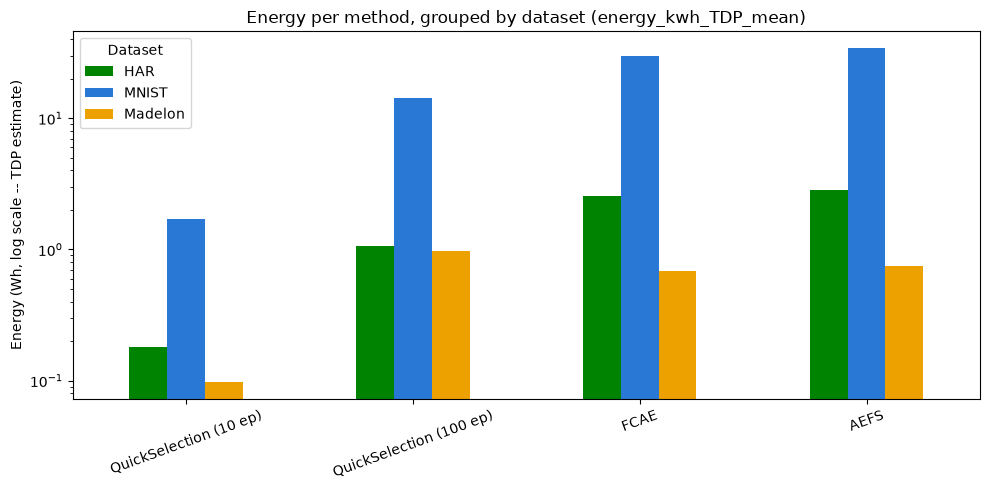

In [32]:
method_order = ['QuickSelection (10 ep)', 'QuickSelection (100 ep)', 'FCAE', 'AEFS']
dataset_colors = {'MNIST': '#2a78d6', 'Madelon': '#eda100', 'HAR': '#008300'}

pivot_energy = (combined_df['energy_kwh_TDP_mean'] * 1000).unstack('Dataset').reindex(method_order)
ax = pivot_energy.plot(kind='bar', figsize=(10, 5), logy=True,
                        color=[dataset_colors[c] for c in pivot_energy.columns])
ax.set_ylabel('Energy (Wh, log scale -- TDP estimate)')
ax.set_title('Energy per method, grouped by dataset (energy_kwh_TDP_mean)')
ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

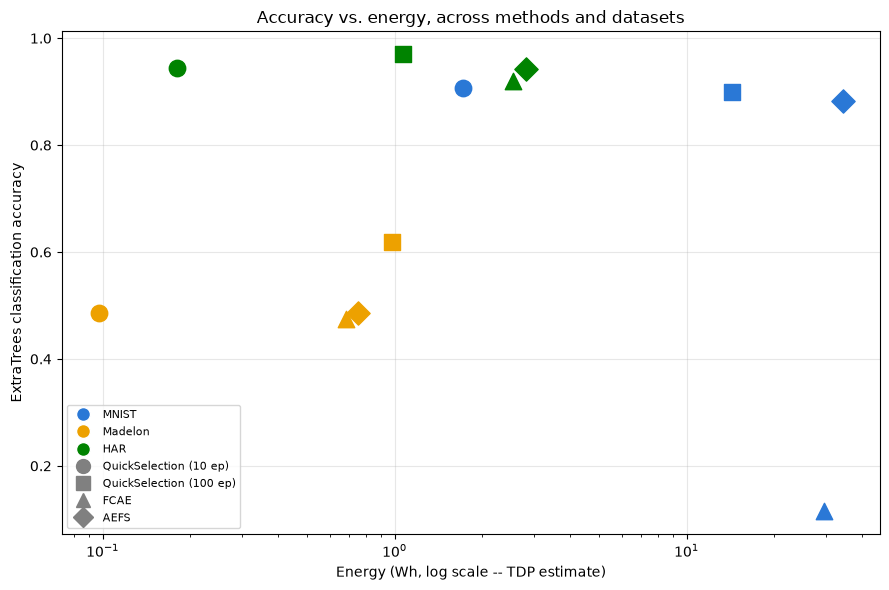

Cheapest (dataset, method): ('Madelon', 'QuickSelection (10 ep)')
Most accurate (dataset, method): ('HAR', 'QuickSelection (100 ep)')
QuickSelection (10 ep): cheapest-to-priciest dataset order = ['Madelon', 'HAR', 'MNIST']
QuickSelection (100 ep): cheapest-to-priciest dataset order = ['Madelon', 'HAR', 'MNIST']
FCAE: cheapest-to-priciest dataset order = ['Madelon', 'HAR', 'MNIST']
AEFS: cheapest-to-priciest dataset order = ['Madelon', 'HAR', 'MNIST']


In [33]:
from matplotlib.lines import Line2D

method_markers = {'QuickSelection (10 ep)': 'o', 'QuickSelection (100 ep)': 's', 'FCAE': '^', 'AEFS': 'D'}

fig, ax = plt.subplots(figsize=(9, 6))
for (dsname, method), row in combined_df.iterrows():
    ax.scatter(row['energy_kwh_TDP_mean'] * 1000, row['ExtraTrees_Accuracy'],
               color=dataset_colors[dsname], marker=method_markers[method], s=140, zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Energy (Wh, log scale -- TDP estimate)')
ax.set_ylabel('ExtraTrees classification accuracy')
ax.set_title('Accuracy vs. energy, across methods and datasets')
ax.grid(alpha=0.3)

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=d, markersize=10) for d, c in dataset_colors.items()]
legend_elements += [Line2D([0], [0], marker=m, color='gray', linestyle='', label=meth, markersize=10) for meth, m in method_markers.items()]
ax.legend(handles=legend_elements, fontsize=8, loc='best')
plt.tight_layout(); plt.show()

cheapest = combined_df['energy_kwh_TDP_mean'].idxmin()
most_accurate = combined_df['ExtraTrees_Accuracy'].idxmax()
print(f"Cheapest (dataset, method): {cheapest}")
print(f"Most accurate (dataset, method): {most_accurate}")
for method in method_order:
    ranking = combined_df.xs(method, level='Method')['energy_kwh_TDP_mean'].sort_values()
    print(f"{method}: cheapest-to-priciest dataset order = {list(ranking.index)}")

# Findings

**QuickSelection reproduced its main Green AI claim**, achieving competitive accuracy with lower training time and estimated energy than the dense autoencoder.

The **approach generalized** across MNIST, Madelon, and HAR, showing similar efficiency trends.

**Energy evaluation **was extended using CodeCarbon, providing a more detailed analysis than the paper's TDP-based estimate.

A bug was identified in the released QuickSelection code, where the input layer could lose all connections during long training. A simple patch prevented this issue and restored stable performance.

Baseline reproduction was less successful, as FCAE and AEFS did not match the paper's reported performance, likely due to missing implementation details and unavailable baseline code.

# Conclusions

- This study successfully reproduced the main contribution of QuickSelection and further evaluated its efficiency from a Green AI perspective. 
- Our experiments confirmed that sparse training can maintain competitive feature-selection performance while significantly reducing computational cost. 
- We also extended the original work by measuring energy consumption and identified a reproducibility issue in the released implementation. Although some results differed from the paper due to unavailable baseline implementations and hardware limitations, the overall findings support QuickSelection as an efficient and reproducible approach for Green AI.